**Universidad Internacional de La Rioja (UNIR) - Máster Universitario en Inteligencia Artificial - Visualización Artificial**

***
Datos del alumno (Nombre y Apellidos): Jose Manuel Pinillos Rubio

Fecha: 1 de diciembre de 2025
***

# <span style="font-size: 20pt; font-weight: bold; color: #0098cd;">Actividad: Mejora de imagen - Operaciones elementales</span>


## 1. Objetivos

Mediante esta actividad se pretende aplicar y comparar distintas técnicas elementales de mejora de imágenes sobre un conjunto de capturas reales tomadas en condiciones de baja iluminación. El objetivo es analizar cómo influyen estas transformaciones en la visibilidad, el contraste y la percepción de los detalles, y valorar cuáles son más eficaces según las características de cada imagen, combinando el análisis visual con medidas objetivas derivadas del histograma.

- Comprender el efecto de las transformaciones de intensidad sobre imágenes con iluminación deficiente.
- Aplicar técnicas de ecualización del histograma para mejorar el contraste global y local.
- Evaluar el impacto de filtros de suavizado sobre el ruido presente en las imágenes.
- Analizar los resultados obtenidos mediante visualizaciones e histogramas.
- Comparar distintos procesamientos en función de la respuesta visual de cada imagen.
- Justificar la selección de cada técnica y su combinación, interpretando sus efectos.

## 2. Descripción de la actividad

En esta actividad se trabajará con un conjunto reducido de imágenes seleccionadas aleatoriamente del *dataset* [The Dark Face](https://www.kaggle.com/datasets/soumikrakshit/dark-face-dataset), una colección de más de 6.000 imágenes capturadas en entornos reales con muy baja iluminación. Las escenas incluyen calles, edificios, parques y otros espacios urbanos durante la noche, lo que representa un contexto especialmente desafiante para cualquier técnica de mejora de imagen. A partir de cuatro imágenes representativas extraídas del conjunto completo, se aplicarán distintos métodos elementales de procesamiento digital con el fin de analizar su capacidad para mejorar el contraste, resaltar detalles ocultos o reducir el ruido visible.

Cada imagen se someterá a varios tipos de transformaciones seleccionadas específicamente para sus características particulares, permitiendo comparar entre distintos enfoques y evaluar de forma visual y cuantitativa la eficacia de cada técnica. El objetivo práctico es explorar el comportamiento de estos métodos cuando se enfrentan a escenas reales en condiciones adversas de iluminación, como ocurre en muchas aplicaciones de visión por computador, seguridad o conducción autónoma. Además de la observación cualitativa, se analizará el impacto de los tratamientos mediante histogramas y métricas sencillas derivadas de la distribución de intensidades.

## 3. Preparación del entorno de trabajo

### 3.1 Importación de librerías

In [ ]:
# Importamos librerías generales
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importamos funciones de skimage para procesamiento y visualización de imágenes
from skimage import io, color, exposure, util, filters
from skimage import img_as_float
from skimage.exposure import equalize_hist, equalize_adapthist, adjust_sigmoid
from skimage.filters import gaussian, median
from skimage.util import random_noise
from skimage.measure import shannon_entropy

# Importamos funciones de scipy para filtrado y convoluciones
from scipy import ndimage
from scipy.ndimage import convolve, gaussian_filter

# Importamos OpenCV para filtros avanzados
import cv2

### 3.2 Definición de ruta y carga de imágenes seleccionadas

In [ ]:
# Carpeta donde tenemos las 4 imágenes
folder = "images"

# Cargamos las imágenes una a una y las convertimos al formato float [0, 1]
image1 = img_as_float(io.imread(os.path.join(folder, "image1.png")))
image2 = img_as_float(io.imread(os.path.join(folder, "image2.png")))
image3 = img_as_float(io.imread(os.path.join(folder, "image3.png")))
image4 = img_as_float(io.imread(os.path.join(folder, "image4.png")))

## 4. Preprocesado y análisis inicial de las imágenes

Antes de aplicar cualquier técnica de mejora, es necesario realizar un análisis exploratorio del conjunto de imágenes para comprender su estructura y condiciones iniciales. En este bloque se evalúa la homogeneidad de las dimensiones, se convierte el contenido a escala de grises y se inspecciona la distribución tonal mediante histogramas. Este análisis previo permite identificar patrones comunes como la baja luminosidad general, así como diferencias sutiles entre imágenes, lo que facilitará posteriormente una aplicación más razonada de los métodos de mejora y una interpretación justificada de sus efectos.

### 4.1 Comprobación de dimensiones y consistencia del conjunto de imágenes

In [ ]:
# Comprobamos que todas las imágenes tienen las mismas dimensiones
images = [image1, image2, image3, image4]

for i, img in enumerate(images, start=1):
    print(f"Dimensiones de la imagen {i}: {img.shape}")

Dimensiones de la imagen 1: (720, 1080, 3)
Dimensiones de la imagen 2: (720, 1080, 3)
Dimensiones de la imagen 3: (720, 1080, 3)
Dimensiones de la imagen 4: (720, 1080, 3)


Este bloque verifica las dimensiones de cada imagen antes de realizar transformaciones. Se comprueba que todas tienen la misma resolución, lo cual justifica que no sea necesario aplicar redimensionado. Al mantener el tamaño original se evita una posible distorsión o pérdida de información, y se garantiza una comparación justa entre procesamientos aplicados a distintas imágenes.

### 4.2 Conversión a escala de grises

In [ ]:
# Convertimos las imágenes a escala de grises usando skimage.color.rgb2gray
gray1 = color.rgb2gray(image1)
gray2 = color.rgb2gray(image2)
gray3 = color.rgb2gray(image3)
gray4 = color.rgb2gray(image4)

Este bloque convierte las imágenes de color al espacio de grises utilizando la función `rgb2gray()` de `skimage.color`. Esta función calcula una media ponderada de los canales R, G y B para reflejar la percepción luminosa del ojo humano. Además, devuelve directamente una imagen tipo *float64* con valores de intensidad normalizados entre $0$ y $1$, lo que permite aplicar directamente transformaciones posteriores sin necesidad de escalar manualmente los datos.

### 4.3 Visualización de imágenes originales y sus histogramas RGB

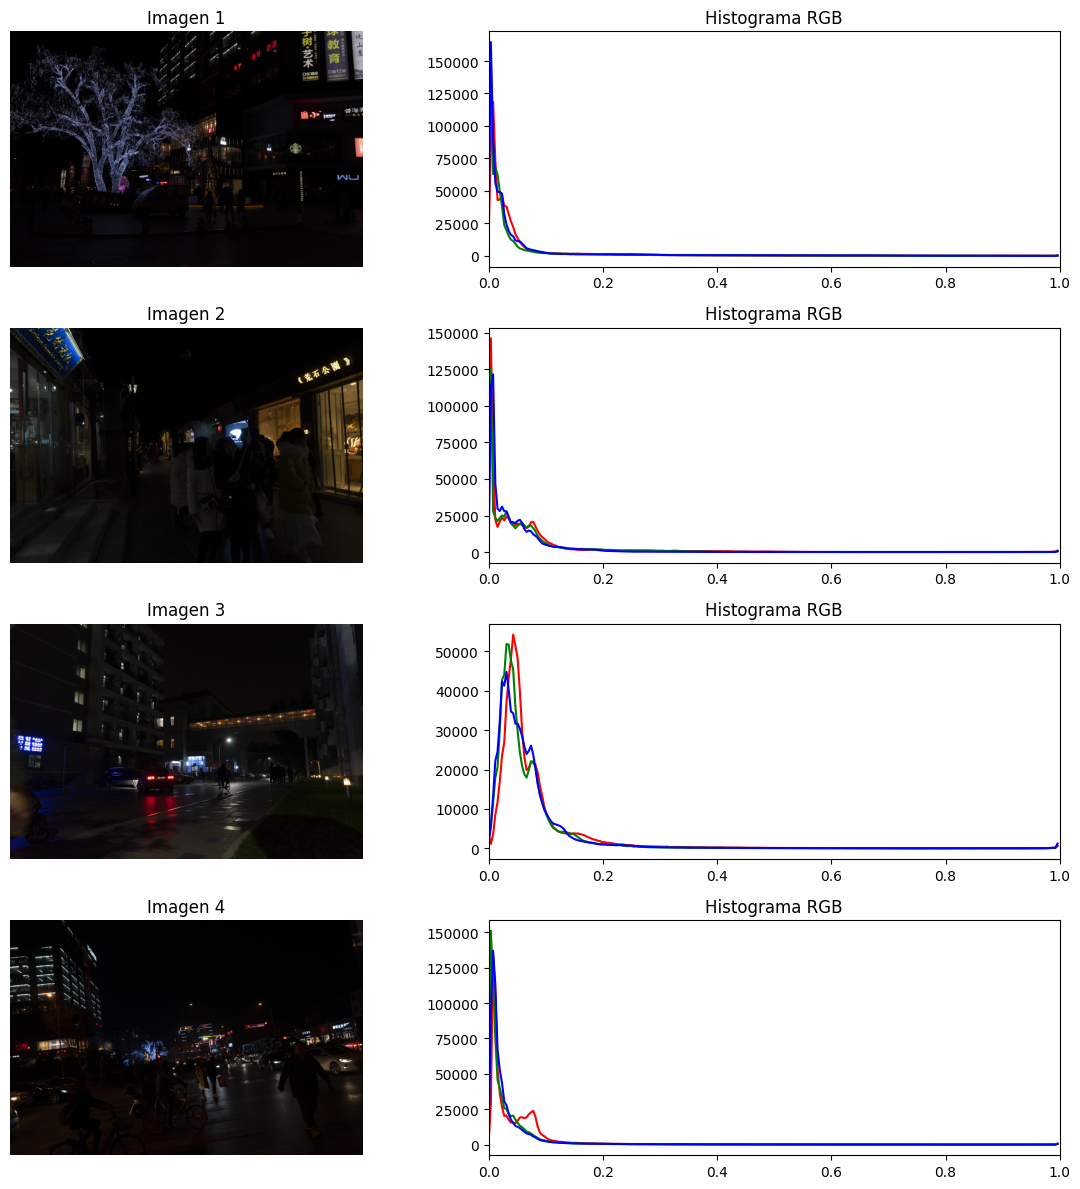

In [ ]:
# Creamos una figura 4x2 para mostrar las imágenes originales y sus histogramas RGB
fig, axes = plt.subplots(4, 2, figsize=(12, 12))

# Definimos las imágenes y títulos
images = [image1, image2, image3, image4]
titles = ["Imagen 1", "Imagen 2", "Imagen 3", "Imagen 4"]

# Iteramos sobre cada imagen
for i in range(4):
    # Mostramos la imagen original
    axes[i, 0].imshow(images[i])
    axes[i, 0].set_title(f"{titles[i]}")
    axes[i, 0].axis("off")

    # Histograma RGB (r, g, b)
    for c, color_channel in enumerate(('r', 'g', 'b')):
        hist, bins = np.histogram(images[i][:, :, c], bins=256, range=(0, 1))
        axes[i, 1].plot(bins[:-1], hist, color=color_channel)

    axes[i, 1].set_title("Histograma RGB")
    axes[i, 1].set_xlim(0, 1)

# Ajustamos la figura
plt.tight_layout()
plt.show()

### 4.4 Visualización de imágenes en escala de grises y sus histogramas

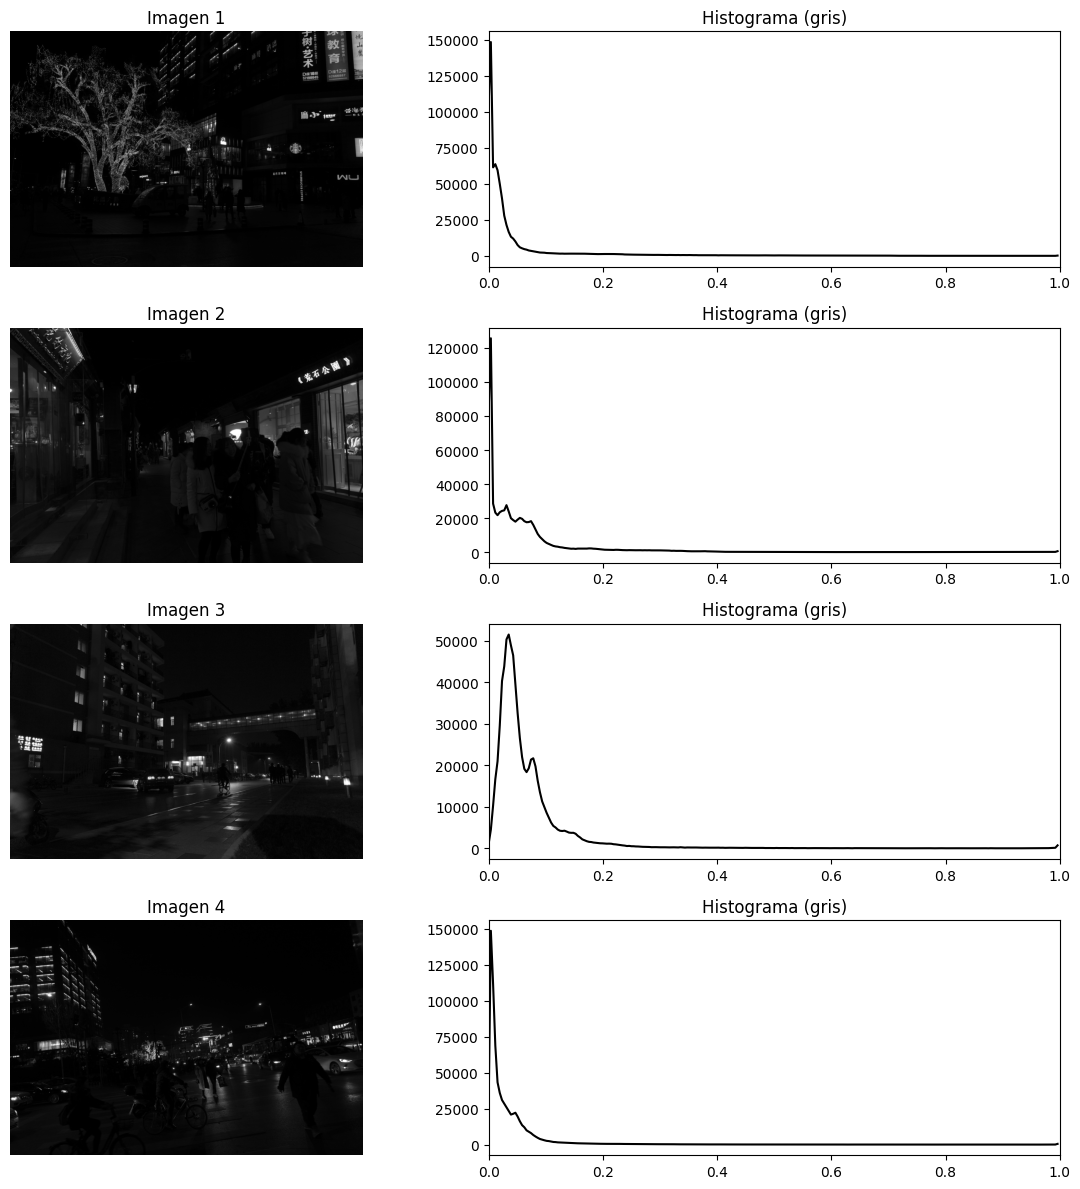

In [ ]:
# Creamos una figura 4x2 para mostrar las imágenes en escala de grises y sus histogramas
fig, axes = plt.subplots(4, 2, figsize=(12, 12))

# Definimos las imágenes en escala de grises y sus títulos
gray_images = [gray1, gray2, gray3, gray4]
titles = ["Imagen 1", "Imagen 2", "Imagen 3", "Imagen 4"]

# Iteramos sobre cada imagen en escala de grises
for i in range(4):
    # Mostramos la imagen en escala de grises
    axes[i, 0].imshow(gray_images[i], cmap='gray')
    axes[i, 0].set_title(f"{titles[i]}")
    axes[i, 0].axis("off")

    # Histograma en escala de grises
    hist, bins = np.histogram(gray_images[i], bins=256, range=(0, 1))
    axes[i, 1].plot(bins[:-1], hist, color='black')
    axes[i, 1].set_title("Histograma (gris)")
    axes[i, 1].set_xlim(0, 1)

# Ajustamos la figura
plt.tight_layout()
plt.show()

### 4.5 Análisis comparativo de intensidad y contenido tonal

Al observar los histogramas correspondientes a las imágenes originales en color, se aprecia una clara concentración de valores en la zona izquierda del eje de intensidades, lo que refleja que la mayoría de píxeles presentan niveles bajos de luminosidad. Esto confirma visualmente lo esperado, ya que las imágenes fueron tomadas en entornos con escasa iluminación. Los tres canales RGB se comportan de forma bastante similar en la mayoría de casos, aunque se aprecian ligeras diferencias en algunas imágenes.

En el caso de la imagen 4, por ejemplo, el canal rojo presenta una elevación más marcada respecto al verde y azul, lo cual puede deberse a la presencia de elementos urbanos con iluminación artificial cálida, como luces de vehículos o carteles. En la imagen 3 también se observa una leve separación entre canales, probablemente por los reflejos de escaparates con distinta temperatura de color. En todos los casos, los valores en las zonas medias y altas del histograma son prácticamente inexistentes, lo que indica una ausencia casi total de regiones muy iluminadas o con alto contraste.

Los histogramas correspondientes a las versiones en escala de grises mantienen la misma distribución general, pero al consolidar la información en un único canal, resulta más sencillo identificar visualmente la acumulación de datos en las intensidades más bajas. Esta representación unificada permite apreciar con mayor claridad los efectos de las futuras transformaciones sobre el contraste y la distribución tonal, facilitando la comparación objetiva entre distintas técnicas de mejora.

## 5. Aplicación selectiva de técnicas de mejora según el contenido de cada imagen

En esta sección se aplican y analizan los efectos de distintas técnicas de procesamiento sobre imágenes nocturnas complejas, evaluando visual y cuantitativamente su impacto en contraste, distribución tonal y claridad estructural.

### 5.1 Transformaciones de intensidad aplicadas a la Imagen 1

La primera imagen seleccionada presenta un contraste muy marcado entre zonas completamente oscuras y puntos de luz muy brillantes, especialmente visibles en los adornos iluminados de un árbol urbano. Este tipo de distribución tonal, con predominio de sombras y algunos detalles sobreexpuestos, es ideal para aplicar transformaciones de intensidad. Estas técnicas permiten modificar la forma en que los valores de gris se distribuyen en la imagen, con el objetivo de **realzar detalles, corregir iluminación no uniforme o mejorar la visibilidad en determinadas regiones**.

En este bloque se aplican cuatro transformaciones: negativo, logarítmica, corrección gamma y una función a trozos. Todas ellas operan directamente sobre la intensidad de cada píxel, sin modificar la estructura espacial ni introducir información externa.

#### **Negativo de la imagen**

El **negativo** es una transformación lineal que invierte los valores de intensidad. Los píxeles oscuros se vuelven claros y viceversa, siguiendo la fórmula:

$$s = 1 - r$$

Donde:

- $\boldsymbol{r}$ representa la intensidad normalizada del píxel original (entre 0 y 1).
- $\boldsymbol{s}$ la intensidad transformada.

Esta operación es útil para **resaltar detalles poco visibles en zonas oscuras** o para analizar estructuras que normalmente se ocultan bajo sombras profundas. En imágenes con predominio de negros, como esta, permite explorar de forma complementaria la distribución espacial del contenido.

#### **Transformación logarítmica**

La **transformación logarítmica** es una técnica no lineal que **expande los valores bajos de intensidad** y **comprime los altos**, permitiendo revelar detalles ocultos en zonas subexpuestas. Se define como:

$$s = C \cdot \log_b(1 + r)$$

Donde:

- $\boldsymbol{s}$ Intensidad del píxel de la imagen de salida (después de la transformación).
- $\boldsymbol{C}$ es una constante de normalización que ajusta el rango de los valores de salida (habitualmente se ajusta entre $[0, 1]$.
- $\boldsymbol{r}$ es la intensidad del píxel de la imagen original.
- $\boldsymbol{b}$: Base del logaritmo (comúnmente 10 o $e$) para el logaritmo natural 'ln').
- $\boldsymbol{r+1}$: Se añade 1 al valor del píxel $(r+1)$ porque $log_b(0)$  no está definido, asegurando que los píxeles negros ($0$) se mapeen a un valor finito (cercano a $0$).

Esta transformación resulta especialmente útil cuando la mayoría de los píxeles se agrupan en el rango bajo del histograma, como en este caso. Al aplicar el logaritmo, pequeñas diferencias en sombras profundas se vuelven más distinguibles.

#### **Corrección gamma**

La **corrección gamma** es una operación no lineal que permite **aclarar u oscurecer** de forma controlada la imagen, sin saturar completamente blancos ni negros. Se expresa mediante la función:

$$s = r^\gamma$$

Donde el parámetro $\boldsymbol{\gamma}$ determina el efecto:
- si $\gamma < 1$, se aclaran las sombras.
- si $\gamma > 1$, se oscurecen las altas luces.

#### **Función a trozos para realce de contraste**

Esta técnica define una función de transformación por tramos, cuyo objetivo es modificar selectivamente las intensidades en tres regiones del histograma: sombras, tonos medios y altas luces. A diferencia de una transformación global, este enfoque permite actuar de forma diferenciada sobre cada intervalo de valores, lo que resulta útil en imágenes con distribución tonal irregular.

$$
s(r) =\begin{cases}
\alpha \cdot r & \text{si} \ r < T_1 \\
\beta\cdot r & \text{si}  \ T_1 \leq r \leq T_2 \\
\gamma \cdot r & \text{si} \ r > T_2 \\
\end{cases}.
$$

Donde:
- $\boldsymbol{\alpha}$, $\boldsymbol{\beta}$ y $\boldsymbol{\gamma}$ son factores de ajuste.
- $\boldsymbol{T_1}$ y $\boldsymbol{T_2}$ son los umbrales que delimitan cada región.

Esta función busca **oscurecer más las sombras profundas**, **realzar las zonas intermedias**, donde suelen concentrarse los detalles relevantes, y **suavizar los brillos excesivos** para evitar saturación. El resultado es una redistribución del contraste que mejora la legibilidad sin romper el equilibrio tonal.

#### 5.1.1 Aplicación del negativo para inversión tonal

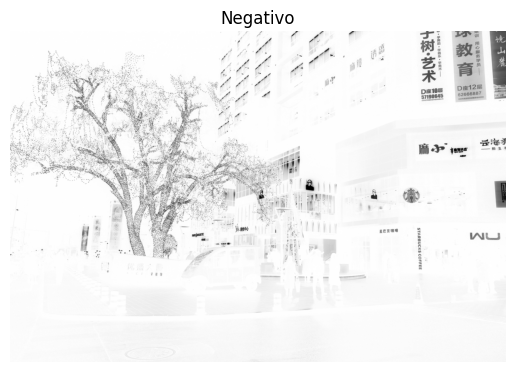

In [ ]:
# Aplicamos el negativo de la imagen en escala de grises
neg1 = 1 - gray1 # Invertimos los valores de intensidad: lo oscuro se vuelve claro y viceversa

# Mostramos la imagen negativa
plt.imshow(neg1, cmap='gray')
plt.title("Negativo")
plt.axis('off')
plt.show()

#### 5.1.2 Transformación logarítmica para realce de zonas oscuras

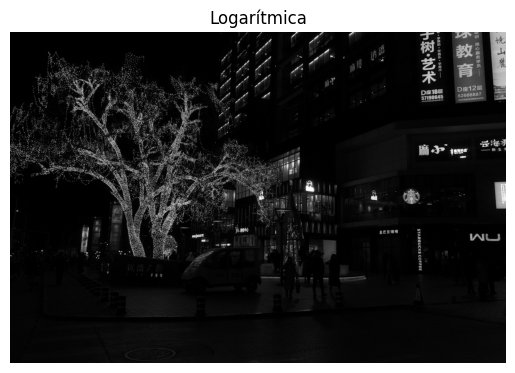

In [ ]:
# Definimos la función de transformación logarítmica con parámetro de escala c
def log_transform(img, c):
    log_image = c * np.log1p(img)  # Aplicamos log(1 + r) para evitar log(0)
    return np.clip(log_image / log_image.max(), 0, 1)  # Normalizamos al rango [0, 1]

# Aplicamos la transformación logarítmica
log1 = log_transform(gray1, c=1.0)

# Mostramos la imagen con transformación logarítmica
plt.imshow(log1, cmap='gray')
plt.title("Logarítmica")
plt.axis('off')
plt.show()

#### 5.1.3 Corrección gamma para equilibrar la luminosidad

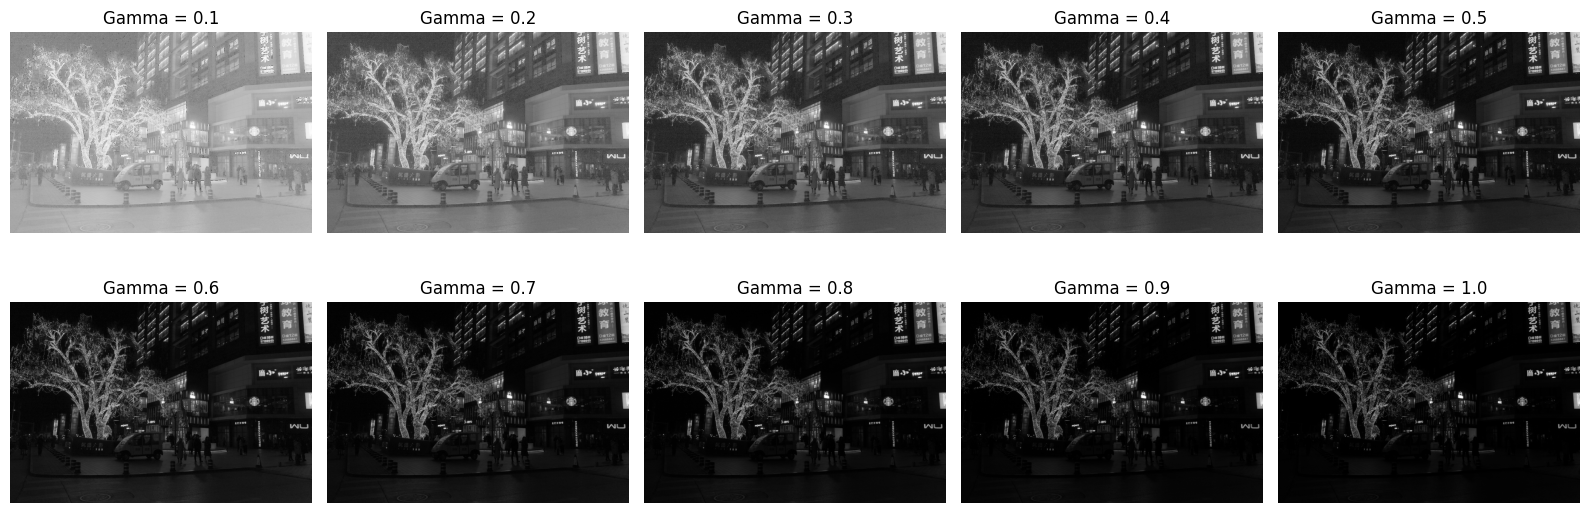

In [ ]:
# Generamos las imágenes gamma y las almacenamos en un diccionario
gamma_images = {}                                       # Diccionario para guardar las imágenes transformadas
gammas = np.arange(0.1, 1.1, 0.1)                       # Valores de gamma a probar

for gamma in gammas:
    gamma_images[round(gamma, 1)] = np.power(gray1, gamma)  # Aplicamos la corrección gamma y guardamos la imagen

# Creamos una figura con 2 filas y 5 columnas
fig, axes = plt.subplots(2, 5, figsize=(16, 6))         # Preparamos la rejilla de visualización

# Mostramos las imágenes almacenadas en el diccionario
for i, gamma in enumerate(gammas):
    row = i // 5                                        # Fila de la figura
    col = i % 5                                         # Columna de la figura
    corrected = gamma_images[round(gamma, 1)]           # Recuperamos la imagen correspondiente

    axes[row, col].imshow(corrected, cmap='gray')       # Mostramos la imagen
    axes[row, col].set_title(f"Gamma = {gamma:.1f}")    # Título con el valor gamma
    axes[row, col].axis('off')                          # Ocultamos los ejes

# Ajustamos el diseño de la figura
plt.tight_layout()
plt.show()

Al aplicar distintos valores de *gamma* observamos cómo se modifica la luminosidad general de la imagen, especialmente en las zonas oscuras. Valores bajos como $\gamma = 0.1$ o $\gamma = 0.2$ producen un **aclarado excesivo**, donde incluso las zonas que originalmente deberían mantenerse oscuras aparecen deslavadas, con pérdida de profundidad y presencia de ruido en áreas que antes eran imperceptibles. Estas versiones pueden resultar útiles si el objetivo es rescatar detalles en sombras muy intensas, pero no conservan el contraste natural.

Con $\gamma = 0.3$ la imagen comienza a mostrar un **equilibrio más adecuado entre luminosidad y contraste**, permitiendo apreciar los detalles de los elementos principales sin perder completamente la atmósfera nocturna. $\gamma = 0.4$ sigue siendo una opción válida, pero incrementa ligeramente la densidad de los negros, ganando fuerza visual en zonas clave a costa de oscurecer algunos detalles secundarios.

A partir de $\gamma = 0.5$, el efecto de aclarado es **menos perceptible**, y la imagen se aproxima progresivamente a su aspecto original, con una leve mejora en los medios tonos pero sin recuperar información relevante en las sombras profundas. En estos casos, la transformación gamma actúa de forma más conservadora, y puede ser útil si no se desea alterar excesivamente la estética original.

Finalmente, valores entre $\gamma = 0.6$ y $\gamma = 1.0$ reducen el impacto de la corrección gamma, dejando la imagen casi inalterada visualmente. Aunque se mantiene el control sobre los brillos intensos, el contraste en zonas oscuras apenas mejora. Estos valores pueden ser apropiados si se busca una transformación muy sutil o si la imagen ya presenta un equilibrio tonal aceptable. Sin embargo, para escenas como esta, estos ajustes resultan poco efectivos en términos de realce visual.

In [ ]:
# Guardamos el gama óptimo en una nueva variable
optimal_gamma = gamma_images[0.3]

#### 5.1.4 Función a trozos para ajuste localizado del contraste

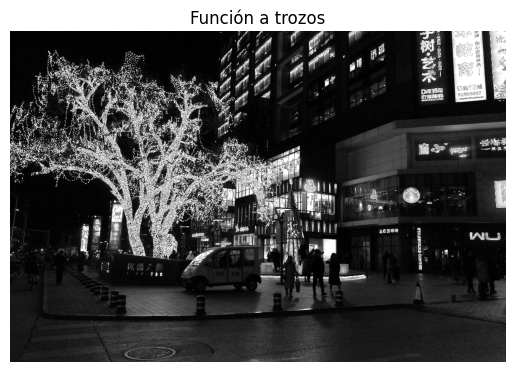

In [ ]:
# Definimos una función a trozos para modificar el contraste según rangos de intensidad
def contraste_trozos(img):
    out = img.copy()
    out[img < 0.3] = img[img < 0.3] * 6 # Atenuamos las sombras profundas
    out[(img >= 0.3) & (img <= 0.7)] = img[(img >= 0.3) & (img <= 0.7)] * 1.5  # Realzamos los tonos medios
    out[img > 0.7] = img[img > 0.7] * 0.8 # Suavizamos las altas luces
    return np.clip(out, 0, 1)  # Limitamos el resultado al rango [0, 1]

# Aplicamos la función de contraste por tramos
trozos1 = contraste_trozos(gray1)

# Mostramos la imagen procesada
plt.imshow(trozos1, cmap='gray')
plt.title("Función a trozos")
plt.axis('off')
plt.show()

Tras probar múltiples combinaciones de parámetros más conservadores, no se logró una mejora apreciable en la visualización. Sin embargo, se encontró una configuración más agresiva que, al incrementar notablemente el factor aplicado a las sombras profundas, permite realzar zonas previamente veladas, mejorando la percepción global de la imagen.

No obstante, esta mejora viene acompañada de un riesgo importante: si el coeficiente aplicado a las zonas oscuras es demasiado alto, los niveles intermedios pueden saturarse, colapsando en el valor máximo permitido ($1.0$). Esto reduce el contraste interno, elimina matices y produce regiones artificialmente "quemadas". Además, una transición mal definida entre tramos puede generar saltos abruptos en el brillo, comprometiendo la suavidad tonal de la imagen.

Este análisis demuestra que la función a trozos puede ser una herramienta eficaz, pero su éxito depende de una correcta adaptación a la distribución tonal concreta de cada imagen. Un diseño inapropiado puede llevar a la pérdida de información, mientras que una parametrización precisa permite mejorar la legibilidad sin introducir artefactos.

#### 5.1.5 Visualización comparativa de transformaciones e histogramas

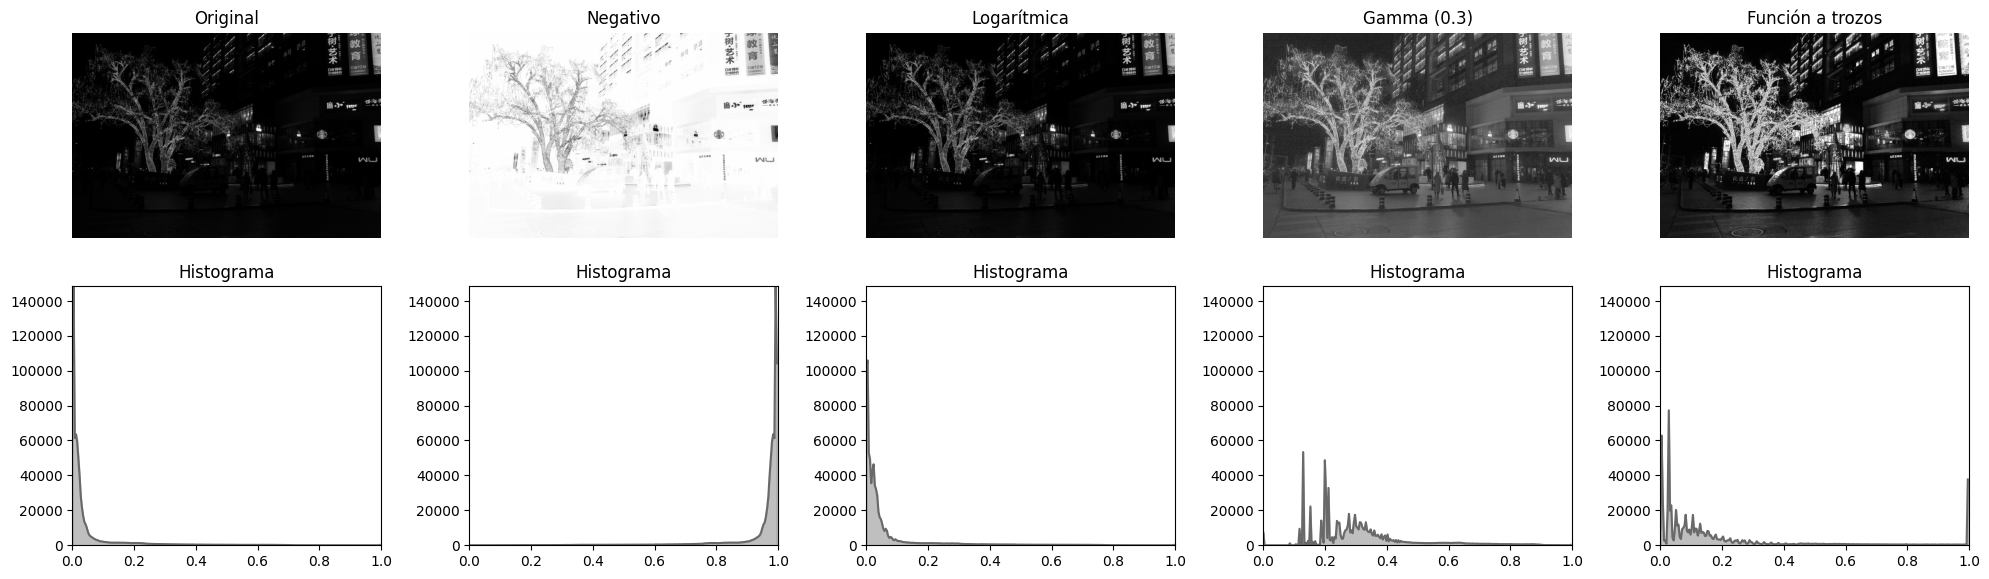

In [ ]:
# Creamos una figura 2x5: primera fila imágenes, segunda fila histogramas
fig, axes = plt.subplots(2, 5, figsize=(20, 6))

# Lista de imágenes y títulos
imagenes = [gray1, neg1, log1, optimal_gamma, trozos1]
titulos = ["Original", "Negativo", "Logarítmica", "Gamma (0.3)", "Función a trozos"]

# Mostramos imágenes en la primera fila
for i in range(5):
    axes[0, i].imshow(imagenes[i], cmap='gray')
    axes[0, i].set_title(titulos[i])
    axes[0, i].axis("off")

# Calculamos el valor máximo entre todos los histogramas para unificar escala
max_val = max(np.histogram(img, bins=256, range=(0, 1))[0].max() for img in imagenes)

# Mostramos histogramas en la segunda fila
for i in range(5):
    hist, bins = np.histogram(imagenes[i], bins=256, range=(0, 1))
    axes[1, i].fill_between(bins[:-1], hist, color='grey', alpha=0.5) # Área traslúcida
    axes[1, i].plot(bins[:-1], hist, color='dimgrey', linewidth=1.5)  # Línea
    axes[1, i].set_title("Histograma")
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_ylim(0, max_val)  # Fijamos escala común
    axes[1, i].grid(False)

# Ajustamos diseño
plt.tight_layout()
plt.show()

En la figura anterior se ilustran los efectos visuales y tonales de cinco transformaciones aplicadas a la imagen original en escala de grises, acompañadas de sus respectivos histogramas para facilitar la comparación cuantitativa.

La **imagen negativa** muestra una inversión completa de los valores de intensidad, lo que se refleja en un histograma simétrico respecto al centro. Las regiones oscuras se transforman en claras y viceversa, lo que puede ser útil para explorar zonas con detalles ocultos en las sombras profundas, aunque en este caso concreto no aporta mejoras relevantes para la legibilidad general.

La **transformación logarítmica** produce un suave realce en las zonas de muy baja intensidad, reduciendo ligeramente la acumulación extrema en torno al cero. No obstante, su impacto visual es limitado, pues la imagen continúa siendo muy oscura y apenas mejora la visibilidad de los elementos clave.

En cambio, la **corrección gamma** con un valor de $\gamma = 0.3$ ofrece una mejora significativa, redistribuyendo los valores hacia la zona baja-media del histograma. El resultado es una imagen más equilibrada, con un mejor aprovechamiento del rango dinámico y una visibilidad notablemente superior. Esta transformación resulta especialmente adecuada para contextos nocturnos como el presente, donde conviene aclarar sin saturar las zonas más claras.

Por último, la **función a trozos**, ajustada con un refuerzo más agresivo en las sombras profundas, consigue una mejora visual significativa, revelando detalles que previamente permanecían ocultos. Esta mejora se aprecia claramente en el histograma, donde los valores inicialmente concentrados en torno a cero se redistribuyen hacia niveles más intermedios, ampliando el rango tonal utilizable. No obstante, también se observa una acumulación de valores cercanos al nivel máximo, lo que indica cierto grado de saturación en zonas muy contrastadas. Este comportamiento confirma que, si bien esta técnica puede ser eficaz, requiere un diseño controlado para evitar la pérdida de gradación tonal y mantener un equilibrio visual adecuado en toda la imagen.

#### 5.1.6 Evaluación cuantitativa de las transformaciones aplicadas

En este apartado se aplica un conjunto de métricas cuantitativas sobre la imagen original y sus versiones transformadas, con el objetivo de analizar de forma objetiva cómo afectan las distintas técnicas a propiedades como el contraste, la distribución de la información y la amplitud tonal. Las métricas utilizadas son:

- **Contraste RMS (*Root Mean Square*)**: mide la dispersión de los valores de intensidad respecto a la media. Un valor mayor indica mayor contraste.
- **Entropía de Shannon**: cuantifica la cantidad de información o incertidumbre. Valores altos sugieren una mayor variedad de intensidades y, por tanto, mayor riqueza visual.
- **Brillo medio**: se calcula como la media aritmética de los valores de intensidad. Indica si la imagen tiende a ser oscura (valores bajos) o clara (valores altos).
- **Percentil 1 (P1)** y **Percentil 99 (P99)**: indican los valores de intensidad por debajo de los cuales se encuentra el 1 % y el 99 % de los píxeles, respectivamente. Permiten identificar zonas extremas de sombras profundas y altas luces, y detectar posibles saturaciones o pérdida de información tonal en los extremos.

In [ ]:
# Lista de imágenes y nombres
imagenes = {
    "Original": gray1,
    "Negativo": neg1,
    "Logarítmica": log1,
    "Gamma 0.3": optimal_gamma,
    "Función a trozos": trozos1
}

# Calculamos las métricas
resultados = {}

for nombre, img in imagenes.items():
    contraste = img.std()  # Contraste RMS
    entropia = shannon_entropy(img)  # Entropía de Shannon
    brillo_medio = img.mean()  # Brillo medio
    p1 = np.percentile(img, 1)  # Percentil 1
    p99 = np.percentile(img, 99)  # Percentil 99

    resultados[nombre] = {
        "Contraste": contraste,
        "Entropía": entropia,
        "Brillo medio": brillo_medio,
        "P1 (1%)": p1,
        "P99 (99%)": p99
    }

# Mostramos los resultados en tabla
df_resultados = pd.DataFrame(resultados).T
display(df_resultados)

,Contraste,Entropía,Brillo medio,P1 (1%),P99 (99%)
Original,0.114076,9.888216,0.054617,0.000283,0.610128
Negativo,0.114076,9.888008,0.945383,0.389872,0.999717
Logarítmica,0.133075,9.888186,0.069909,0.000408,0.687175
Gamma 0.3,0.165821,9.888078,0.321621,0.086182,0.862236
Función a trozos,0.270617,9.223653,0.204740,0.001696,1.000000


Los valores obtenidos muestran que el **contraste** de la imagen original y su negativo es idéntico ($0.1141$), lo cual es coherente, ya que ambas contienen la misma dispersión tonal pero invertida. También la **entropía** apenas varía, lo que confirma que invertir la imagen no altera la cantidad de información; cualquier diferencia mínima se debe probablemente a efectos numéricos.

Las transformaciones **logarítmica** y **gamma** aumentan progresivamente el contraste, siendo especialmente notable con gamma ($0.1658$), y manteniendo una entropía elevada. No obstante, la **función a trozos**, ajustada de forma agresiva, es la que genera el mayor contraste ($0.2706$), lo que refleja el fuerte realce aplicado en sombras medias. Esta mejora se traduce en una mayor visibilidad, pero también en una caída importante de entropía ($9.22$), lo que sugiere una **pérdida de diversidad tonal**, probablemente por saturación en zonas que alcanzan el valor máximo ($1.0$).

El **brillo medio** varía significativamente entre técnicas: en el **negativo**, el valor se invierte y alcanza $0.9454$, mientras que en la logarítmica apenas aumenta ligeramente. En cambio, la **gamma ($\boldsymbol{0.3}$)** produce una imagen más luminosa que la original ($0.3216$), manteniendo buena visibilidad sin saturación excesiva. En la función a trozos, aunque mejora la visibilidad en regiones específicas, **el brillo medio sigue siendo bajo ($0.2047$)**, lo que refleja que muchas zonas continúan en niveles de oscuridad.

Los **percentiles P1 y P99** confirman estos hallazgos. P1 muestra cuán profundas siguen siendo las sombras ($0.0003$ en original vs. $0.0017$ en función a trozos), mientras que P99 nos informa sobre el alcance de las luces altas. La transformación por tramos lleva este valor al **límite de saturación ($\boldsymbol{1.0}$)**, lo que confirma que algunas regiones han sido empujadas al blanco absoluto, comprometiendo el detalle fino.

### 5.2 Procesamientos basados en filtrado y ecualización aplicados a la Imagen 2

La segunda imagen del conjunto presenta un contexto distinto al de la imagen anterior. En este caso, la escena contiene una iluminación más homogénea y falta de definición en algunas estructuras. La tonalidad general se sitúa en niveles bajos y medios, con escasa presencia de blancos intensos y una distribución relativamente uniforme en la parte izquierda del histograma. Este tipo de imágenes se benefician especialmente de técnicas que actúan sobre el contraste local y de métodos de filtrado que suavizan el ruido o realzan bordes y detalles estructurales.

A diferencia del bloque anterior, en este apartado se aplicarán **procesamientos espaciales basados en filtros**. Estas técnicas consideran no solo la intensidad de cada píxel, sino también la de sus vecinos, permitiendo modificar la imagen de acuerdo a su contexto local. Son fundamentales en tareas como la **reducción de ruido**, el **suavizado**, la **detección de contornos** o el **realce de bordes**.

En este bloque se se evaluarán cuatro estrategias de procesamiento: filtro de media, filtro de mediana, filtro gaussiano y ecualización del histograma.

#### **Filtro de media**

El **filtro de media** es una técnica de suavizado lineal que reemplaza cada píxel por el promedio de los valores de intensidad en su vecindario. Su objetivo principal es reducir el ruido de alta frecuencia, eliminando variaciones abruptas y suavizando la imagen. Se define como:

$$s(x, y) = \frac{1}{N} \sum_{(i,j) \in \Omega} r(x+i, y+j)$$

Donde:

- $\boldsymbol{\Omega}$ es el vecindario definido por una ventana (por ejemplo, 3×3).
- $\boldsymbol{N}$ es el número de píxeles en dicha ventana.
- $\boldsymbol{r(x+i, y+j)}$ son las intensidades vecinas.
- $\boldsymbol{s(x, y)}$ es el nuevo valor asignado al píxel central.

Aunque es eficaz eliminando ruido aleatorio, puede **difuminar bordes y detalles**, por lo que su uso requiere un balance entre suavizado y pérdida de definición.

#### **Filtro de mediana**

El **filtro de mediana** es un método de suavizado no lineal que sustituye cada píxel por el valor **mediano** de su vecindario. Es especialmente eficaz contra **ruido impulsivo** (por ejemplo, ruido sal y pimienta), preservando mejor los bordes que el filtro de media.

$$s(x, y) = \text{mediana} \left\{ r(x+i, y+j) \ \big| \ (i,j) \in \Omega \right\}$$

A diferencia del filtro de media, **no promedia los valores**, sino que toma el valor central tras ordenarlos, lo que evita que valores extremos afecten al resultado. Es ideal cuando se busca **suavizar sin perder contornos nítidos**.

#### **Filtro gaussiano**

El **filtro gaussiano** realiza un suavizado utilizando una máscara cuyos pesos siguen una distribución gaussiana. De este modo, los píxeles más cercanos al centro de la ventana tienen mayor peso, lo que permite un desenfoque más natural y progresivo.

$$G(x,y) = \dfrac{1}{2\pi\sigma^2} \cdot e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

Donde:
- $\boldsymbol{\sigma}$ es la desviación estándar, que controla el grado de suavizado.
- Una $\boldsymbol{\sigma}$ mayor implica un desenfoque más fuerte.

Este filtro es útil tanto para **reducir ruido de alta frecuencia** como para **preprocesar imágenes antes de detectar bordes** u otras operaciones.

#### **Ecualización del histograma**

La **ecualización del histograma** es una técnica de transformación global que modifica la imagen para aprovechar **de forma más uniforme todo el rango de intensidades posibles**. Aumenta el contraste en regiones planas del histograma y puede mejorar significativamente la visibilidad en imágenes con bajo rango dinámico.

El proceso redistribuye los valores de intensidad de modo que el histograma resultante sea más plano o uniforme:

$$s = (L-1) \cdot \sum_{j=0}^{r} p_r(j)$$

Donde:

- $\boldsymbol{s}$ es el nuevo valor de intensidad.
- $\boldsymbol{L}$ es el número total de niveles de gris.
- $\boldsymbol{p_r(j)}$ es la probabilidad de aparición del nivel $j$.
- $\boldsymbol{r}$ es el valor de intensidad original.

Esta técnica **no tiene en cuenta la vecindad**, por lo que puede generar artefactos en regiones con gradientes suaves, aunque su efecto general sobre el contraste es muy útil.

#### 5.2.1 Aplicación del filtro de media para suavizado general

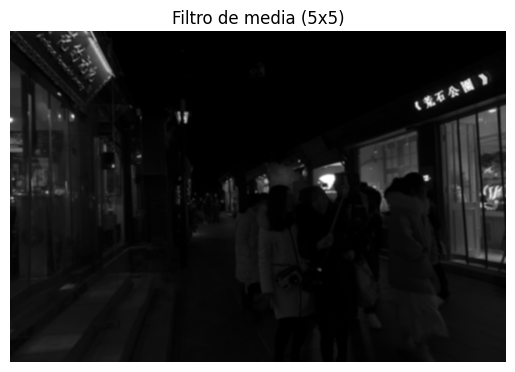

In [ ]:
# Aplicamos un filtro de media con ventana 5x5
media2 = ndimage.uniform_filter(gray2, size=5)

# Mostramos la imagen resultante
plt.imshow(media2, cmap='gray')
plt.title("Filtro de media (5x5)")
plt.axis('off')
plt.show()

#### 5.2.2 Aplicación del filtro de mediana para eliminación de ruido impulsivo

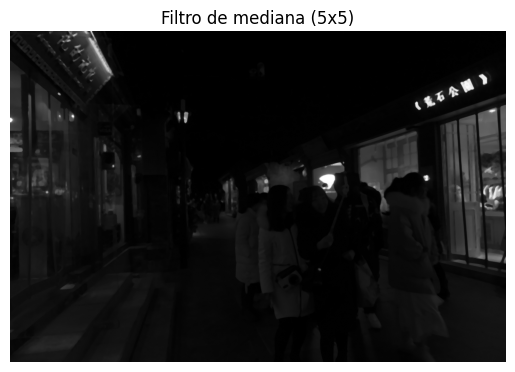

In [ ]:
# Aplicamos un filtro de mediana con ventana 5x5
mediana2 = ndimage.median_filter(gray2, size=5)

# Mostramos la imagen resultante
plt.imshow(mediana2, cmap='gray')
plt.title("Filtro de mediana (5x5)")
plt.axis('off')
plt.show()

#### 5.2.3 Aplicación del filtro gaussiano para suavizado controlado

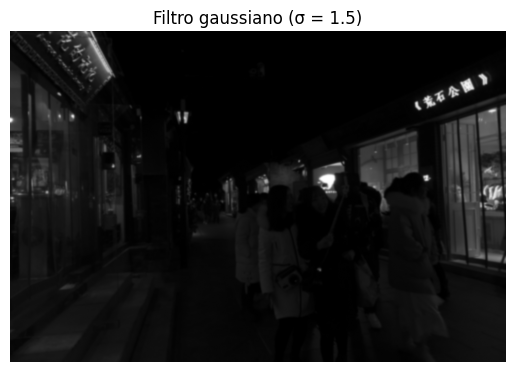

In [ ]:
# Aplicamos un filtro gaussiano con sigma=1.5
gauss2 = ndimage.gaussian_filter(gray2, sigma=1.5)

# Mostramos la imagen resultante
plt.imshow(gauss2, cmap='gray')
plt.title("Filtro gaussiano (σ = 1.5)")
plt.axis('off')
plt.show()

#### 5.2.4 Ecualización del histograma para mejora global del contraste

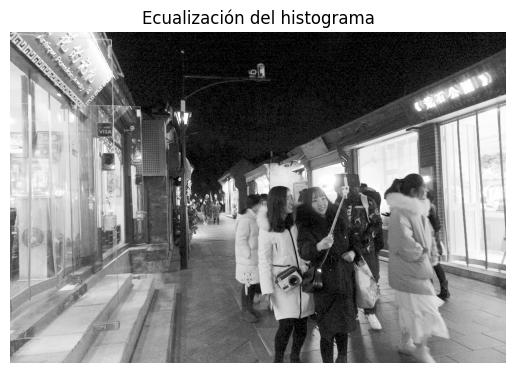

In [ ]:
# Ecualizamos el histograma de la imagen
ecualizada2 = exposure.equalize_hist(gray2)

# Mostramos la imagen ecualizada
plt.imshow(ecualizada2, cmap='gray')
plt.title("Ecualización del histograma")
plt.axis('off')
plt.show()

#### 5.2.5 Visualización comparativa de filtrados y ecualización

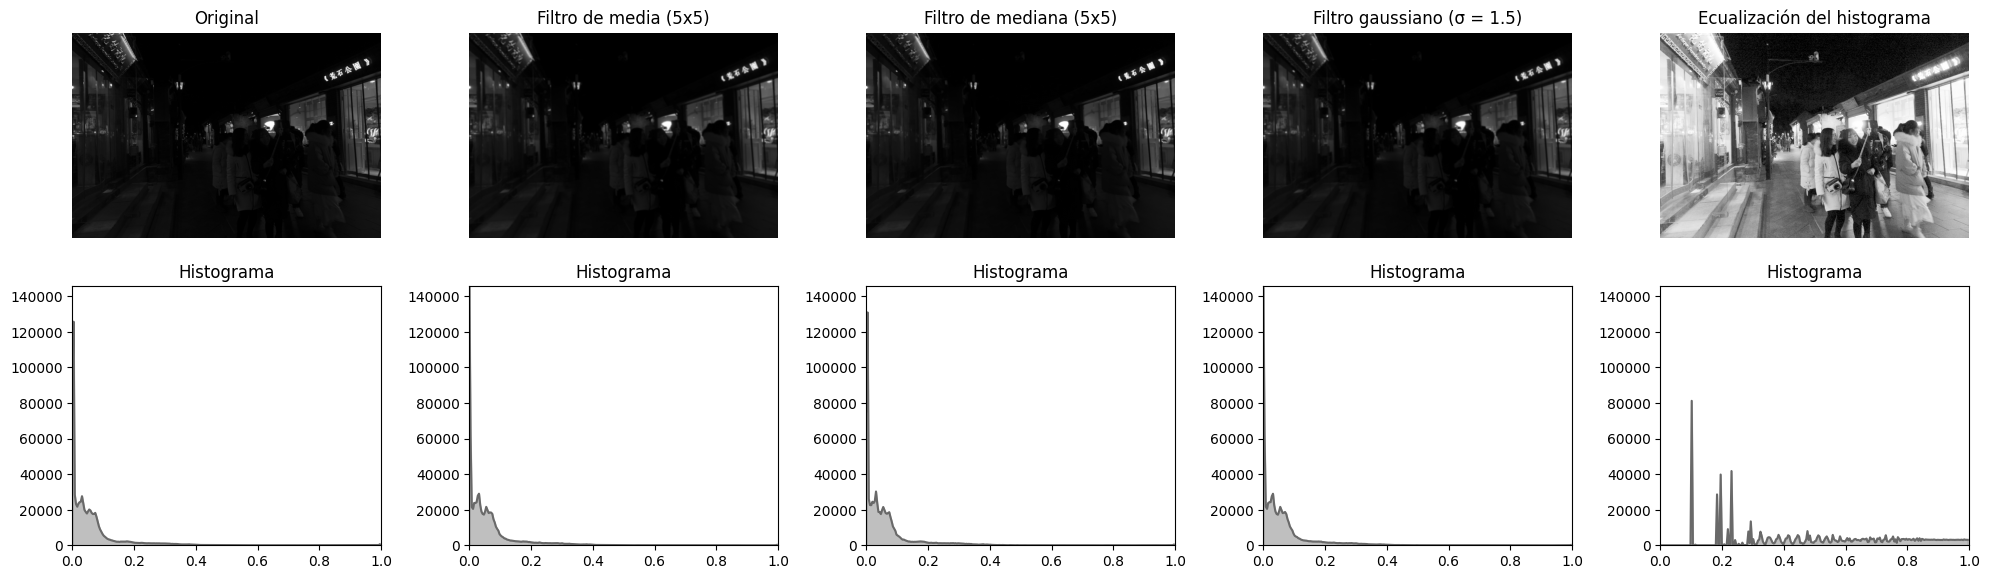

In [ ]:
# Creamos una figura 2x5: primera fila imágenes, segunda fila histogramas
fig, axes = plt.subplots(2, 5, figsize=(20, 6))

# Lista de imágenes y títulos
imagenes = [gray2, media2, mediana2, gauss2, ecualizada2]
titulos = ["Original", "Filtro de media (5x5)", "Filtro de mediana (5x5)", "Filtro gaussiano (σ = 1.5)", "Ecualización del histograma"]

# Mostramos imágenes en la primera fila
for i in range(5):
    axes[0, i].imshow(imagenes[i], cmap='gray')
    axes[0, i].set_title(titulos[i])
    axes[0, i].axis("off")

# Calculamos el valor máximo entre todos los histogramas para unificar escala
max_val = max(np.histogram(img, bins=256, range=(0, 1))[0].max() for img in imagenes)

# Mostramos histogramas en la segunda fila
for i in range(5):
    hist, bins = np.histogram(imagenes[i], bins=256, range=(0, 1))
    axes[1, i].fill_between(bins[:-1], hist, color='grey', alpha=0.5) # Área traslúcida
    axes[1, i].plot(bins[:-1], hist, color='dimgrey', linewidth=1.5)  # Línea
    axes[1, i].set_title("Histograma")
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_ylim(0, max_val)  # Fijamos escala común
    axes[1, i].grid(False)

# Ajustamos diseño
plt.tight_layout()
plt.show()

En la figura anterior se muestran los resultados de aplicar tres filtros espaciales (media, mediana y gaussiano) y una técnica de ecualización del histograma sobre la imagen original.

Los **filtros de media, mediana y gaussiano**, aplicados con una máscara de tamaño moderado (5×5) o con un sigma estándar ($\sigma=1.5$), presentan un efecto visual muy limitado sobre esta imagen concreta. Aunque su objetivo es suavizar o reducir el ruido, el resultado es casi imperceptible debido a que la imagen original ya presenta un nivel de detalle bajo y una alta concentración de píxeles en el rango oscuro. Esto se confirma en los histogramas, que mantienen prácticamente la misma forma que el original, con una fuerte acumulación en intensidades bajas y sin expansión significativa del rango dinámico.

En cambio, la **ecualización del histograma** produce un cambio notable tanto visual como gráficamente. La imagen aparece significativamente más clara, con detalles previamente invisibles que ahora se hacen evidentes, especialmente en las zonas en sombra. Este cambio se refleja en el histograma, donde las intensidades se redistribuyen de manera mucho más uniforme a lo largo del rango $[0, 1]$. La ecualización extiende el espectro tonal y permite que la imagen aproveche mejor todo el rango disponible de intensidades.

No obstante, este proceso también tiene consecuencias no deseadas: se observa un incremento del ruido en las zonas oscuras y la aparición de regiones "quemadas" en las luces altas, donde se pierde detalle por saturación. Esta doble cara de la ecualización sugiere que podría ser beneficioso **aplicarla como paso previo** a otros filtros, como los suavizados, para corregir estos defectos.

#### 5.2.6 Aplicación combinada de técnicas para mejora visual progresiva

Tras el análisis individual de las técnicas de ecualización y filtrado, en este apartado se propone una estrategia combinada que simula un flujo de mejora visual más realista. Se parte de una **imagen ecualizada** y se aplican sobre ella diversos filtros espaciales con el fin de observar cómo modifican el resultado final.

La combinación tiene como objetivos principales: **suavizar artefactos o ruido** que pudieran haberse amplificado por la ecualización y **comparar cómo actúa cada tipo de filtro** cuando se aplica tras una expansión del contraste.

Es importante destacar que **la ecualización se realiza una sola vez** sobre la imagen original (`gray2`). A partir de esa imagen ecualizada se aplican por separado:

- Filtro de media (promediador),
- Filtro de mediana (supresor de ruido impulsivo),
- Filtro gaussiano (suavizado suave controlado por desviación típica).

Esto permite observar con claridad el efecto de cada técnica cuando se emplea como postprocesado tras la ecualización.

##### 5.2.6.1 Aplicación del filtro de media sobre la imagen ecualizada

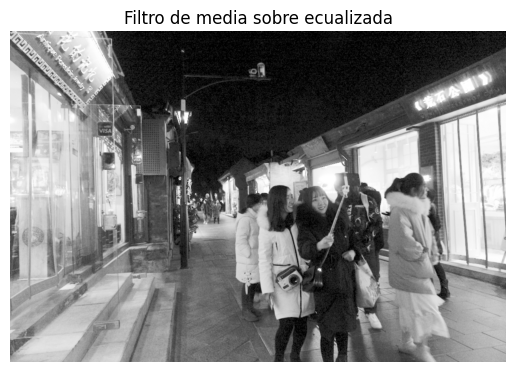

In [ ]:
# Aplicamos el filtro de media sobre la imagen ecualizada
eq_media = ndimage.uniform_filter(ecualizada2, size=2)

# Mostramos la imagen suavizada
plt.imshow(eq_media, cmap='gray')
plt.title("Filtro de media sobre ecualizada")
plt.axis('off')

plt.show()


##### 5.2.6.2 Aplicación del filtro de mediana sobre la imagen ecualizada

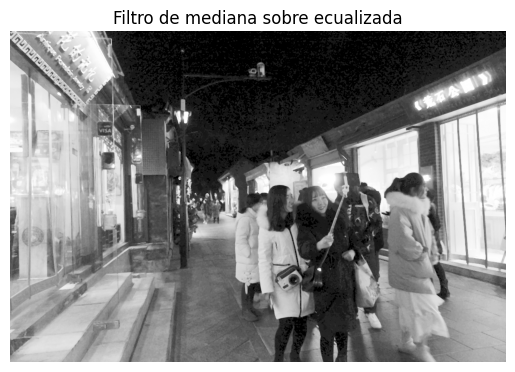

In [ ]:
# Aplicamos un filtro de mediana 5x5 a la imagen ecualizada
eq_mediana = ndimage.median_filter(ecualizada2, size=3)

# Mostramos el resultado
plt.imshow(eq_mediana, cmap='gray')
plt.title("Filtro de mediana sobre ecualizada")
plt.axis("off")
plt.show()

##### 5.2.6.3 Aplicación del filtro gaussiano sobre la imagen ecualizada

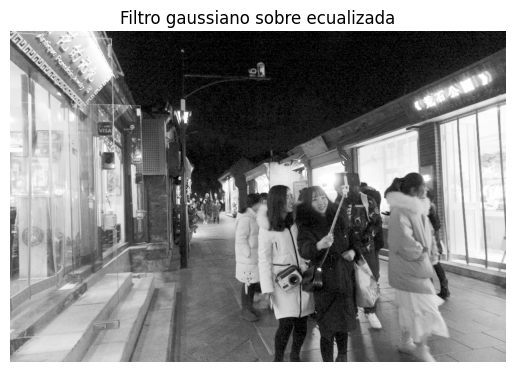

In [ ]:
# Aplicamos un filtro gaussiano con sigma=0.5 a la imagen ecualizada
eq_gauss = ndimage.gaussian_filter(ecualizada2, sigma=0.5)

# Mostramos el resultado
plt.imshow(eq_gauss, cmap='gray')
plt.title("Filtro gaussiano sobre ecualizada")
plt.axis("off")
plt.show()

##### 5.2.6.4 Visualización comparativa de filtros combinados

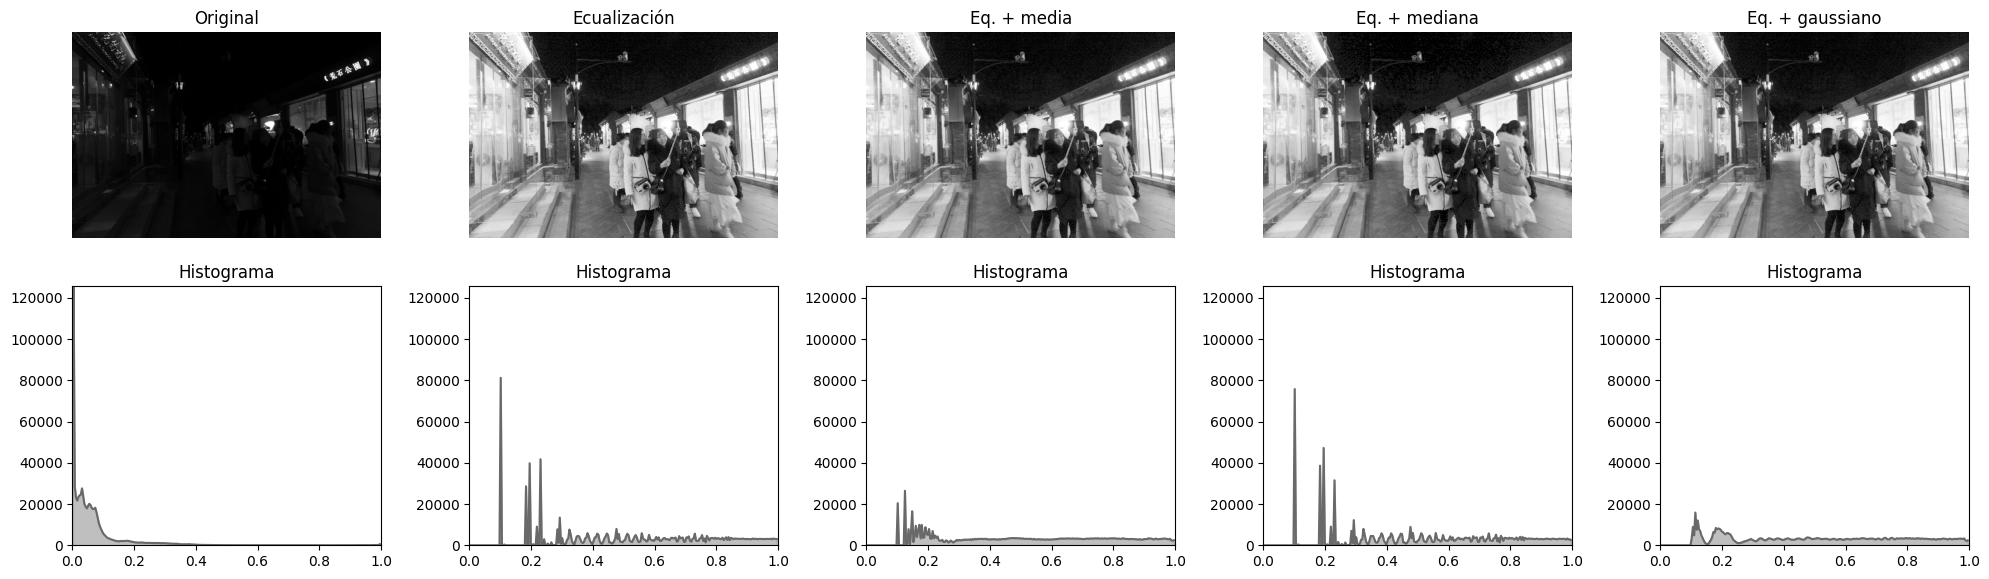

In [ ]:
# Lista de imágenes y títulos
imagenes_comb = [
    gray2,            # Imagen original
    ecualizada2,      # Imagen ecualizada
    eq_media,         # Ecualizada + media
    eq_mediana,       # Ecualizada + mediana
    eq_gauss          # Ecualizada + gaussiano
]

titulos_comb = [
    "Original",
    "Ecualización",
    "Eq. + media",
    "Eq. + mediana",
    "Eq. + gaussiano"
]

# Creamos figura 2x5: imágenes arriba, histogramas abajo
fig, axes = plt.subplots(2, 5, figsize=(20, 6))

# Mostramos las imágenes en la primera fila
for i in range(5):
    axes[0, i].imshow(imagenes_comb[i], cmap='gray')
    axes[0, i].set_title(titulos_comb[i])
    axes[0, i].axis("off")

# Calculamos el valor máximo para unificar escala de histogramas
max_val_comb = max(np.histogram(img, bins=256, range=(0, 1))[0].max() for img in imagenes_comb)

# Mostramos histogramas en la segunda fila
for i in range(5):
    hist, bins = np.histogram(imagenes_comb[i], bins=256, range=(0, 1))
    axes[1, i].fill_between(bins[:-1], hist, color='grey', alpha=0.5)
    axes[1, i].plot(bins[:-1], hist, color='dimgrey', linewidth=1.5)
    axes[1, i].set_title("Histograma")
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_ylim(0, max_val_comb)
    axes[1, i].grid(False)

# Ajustamos el diseño
plt.tight_layout()
plt.show()

La imagen original, como ya se analizó anteriormente, presenta una dominancia de tonos oscuros, con pérdida evidente de detalle en amplias regiones de sombra. La ecualización del histograma logra un cambio notable, tanto visual como tonalmente, revelando estructuras previamente ocultas y redistribuyendo la intensidad hacia un rango más amplio. Esto se refleja claramente en el histograma, que pasa de estar concentrado en la zona baja a ocupar casi todo el eje horizontal, aunque con acumulaciones en zonas específicas que pueden originar ruido o saturación en regiones claras.

La **ecualización del histograma** transforma profundamente la imagen. Ahora la distribución de intensidades se expande y ocupa gran parte del eje dinámico, algo claramente visible en el histograma, donde aparecen picos distribuidos a lo largo de todo el rango. Este ensanchamiento permite recuperar detalles que antes estaban ocultos, especialmente en zonas de sombra y en la estructura urbana del entorno. El rostro y vestimenta de las personas adquieren detalles previamente inexistentes, y las superficies iluminadas muestran mayor riqueza tonal. Sin embargo, la aparición de picos muy concentrados, especialmente en intensidades medias-bajas, sugiere cierta amplificación del ruido original y la posibilidad de saturación local en regiones muy iluminadas.

La aplicación del **filtro de media sobre la imagen ecualizada (2x2)** produce un aplanamiento del ruido más evidente en las transiciones suaves, especialmente en fachadas y áreas de sombra. El filtro atenúa la fragmentación tonal introducida por la ecualización y suaviza irregularidades. La elección de un kernel pequeño evita que la imagen pierda demasiado detalle, y el resultado visual mantiene la estructura global con una mejora evidente en la uniformidad. En el histograma se aprecia una reducción clara de los picos más pronunciados, sobre todo en las intensidades bajas donde la ecualización generaba artefactos tonales. El resultado final es más estable, con menor variabilidad abrupta entre tonos cercanos.

El **filtro de mediana (3x3)** muestra un comportamiento muy diferente. Aunque la mediana es excelente para eliminar ruido impulsivo, su impacto en esta imagen, que no presenta ruido sal y pimienta, no resulta beneficioso. Visualmente introduce una ligera rugosidad en zonas con texturas continuas y difumina bordes finos, lo que deteriora la nitidez percibida. En regiones faciales se observa una pérdida de microdetalle y un aspecto menos natural. El histograma confirma esta escasa aportación, donde las variaciones respecto a la ecualización pura son mínimas, con solo una ligera amortiguación de valores intermedios. Esto evidencia que el filtro no actúa sobre un tipo de ruido presente, sino que altera estructuras importantes sin aportar una mejora real.

El **filtro gaussiano con** $\boldsymbol{\sigma=0.5}$, por el contrario, ofrece un equilibrio excepcional entre suavizado y conservación del detalle. Su acción continua y progresiva, frente al carácter más agresivo y no lineal de la mediana, permite reducir la dureza tonal introducida por la ecualización sin generar artefactos visibles. La textura de la piel, los contornos de las prendas y la iluminación urbana mantienen su integridad, pero con un aspecto más natural y menos granulado. En el histograma se observa un comportamiento similar al filtro de media, aunque más controlado: desaparecen las oscilaciones abruptas, pero se preserva una variabilidad tonal suficiente para mantener la sensación de detalle. Esta estabilidad lo convierte en el filtro más adecuado para suavizar imágenes ecualizadas sin comprometer su estructura.

En conjunto, el análisis confirma que **la combinación de ecualización con filtros espaciales permite corregir muchas de las limitaciones inherentes a cada técnica aplicada de forma aislada**. La ecualización incrementa el contraste y revela detalles profundos, pero puede introducir ruido y discontinuidades tonales. La media suaviza de forma global pero tiende a difuminar estructuras finas. La mediana es útil únicamente en situaciones de ruido impulsivo y, en su ausencia, degrada la imagen. El filtro gaussiano emerge como la opción más equilibrada, mitigando el ruido amplificado por la ecualización y preservando una apariencia visual coherente.

Finalmente, los resultados sugieren que una estrategia avanzada debería contemplar la **aplicación selectiva y adaptativa** de estas técnicas. Mientras que la ecualización global resulta efectiva para expandir el rango dinámico, su combinación con filtrado gaussiano podría aplicarse de manera local sobre regiones homogéneas o con texturas suaves, mientras que la media podría refinar zonas con variabilidad más compleja.

#### 5.2.7 Evaluación cuantitativa de los filtros combinadas aplicados

In [ ]:
# Lista de imágenes y nombres
imagenes = {
    "Original": gray2,
    "Ecualizada": ecualizada2,
    "Eq + media": eq_media,
    "Eq + mediana": eq_mediana,
    "Eq + gaussiano": eq_gauss
}

# Calculamos las métricas
resultados = {}
for nombre, img in imagenes.items():
    contraste = img.std()  # Contraste RMS
    entropia = shannon_entropy(img)  # Entropía de Shannon
    brillo_medio = img.mean()  # Brillo medio
    p1 = np.percentile(img, 1)  # Percentil 1
    p99 = np.percentile(img, 99)  # Percentil 99

    resultados[nombre] = {
        "Contraste": contraste,
        "Entropía": entropia,
        "Brillo medio": brillo_medio,
        "P1 (1%)": p1,
        "P99 (99%)": p99
    }

# Mostramos los resultados en tabla
df_resultados = pd.DataFrame(resultados).T
display(df_resultados)

,Contraste,Entropía,Brillo medio,P1 (1%),P99 (99%)
Original,0.101691,10.085311,0.065335,0.001116,0.447359
Ecualizada,0.276138,9.988998,0.515714,0.105009,0.990107
Eq + media,0.273341,18.006105,0.515520,0.105009,0.987350
Eq + mediana,0.275504,9.872819,0.516114,0.105009,0.989097
Eq + gaussiano,0.273843,19.539507,0.515714,0.106467,0.987199


Los resultados muestran como la **imagen original** presenta un contraste muy bajo ($\approx 0.1017$), lo que concuerda con la distribución tonal previamente analizada. Tras aplicar la ecualización del histograma, el **contraste se incrementa notablemente hasta** $\boldsymbol{0.2761}$, valor que se mantiene prácticamente estable tras aplicar los filtros espaciales. Esto indica que los filtros no alteran la dispersión tonal global, sino que actúan principalmente a nivel local para suavizar sin reducir la amplitud del contraste.

La **entropía** de la imagen original es la más alta del conjunto ($\approx 10.0853$), lo cual es lógico dado que presenta muchos niveles de gris muy próximos y mal definidos, generando una distribución aparentemente “desordenada” desde el punto de vista informativo. Curiosamente, la **ecualización reduce ligeramente la entropía** ($\approx 9.989$), lo que puede deberse a la creación de agrupaciones tonales más marcadas (valores que se repiten con mayor frecuencia tras redistribuir el histograma), aunque visualmente haya una ganancia de detalle.

El filtro de **mediana** mantiene esta tendencia de reducción ($\approx 9.87$), mientras que los filtros de **media y gaussiano provocan un incremento espectacular de la entropía** ($\approx 18.0$ y $\approx 19.5$, respectivamente). Esto se debe a que, al suavizar transiciones y crear valores intermedios más diversos, **dispersan la información en más niveles de gris**, haciendo que la distribución sea más uniforme y “rica” desde el punto de vista estadístico. No implica necesariamente mayor legibilidad visual, pero sí mayor variabilidad tonal.

El **brillo medio** sube de forma notable con la ecualización (de $0.065$ a $\approx 0.515$), situando la imagen en un rango mucho más perceptible. Todos los filtros mantienen este nivel prácticamente sin cambios, lo que indica que **no alteran el balance luminoso global**, sino únicamente la forma en que se transiciona entre regiones.

Los percentiles P1 y P99 muestran una **ampliación clara del rango efectivo tras la ecualización**: P1 se eleva de $0.0011$ a $\approx 0.105$, y P99 alcanza valores próximos a $1.0$ ($\approx 0.99$). Esta expansión confirma que la imagen ahora utiliza mejor todo el rango dinámico.

Los filtros apenas modifican los percentiles, aunque el gaussiano **aumenta ligeramente el P1** hasta $\approx 0.1065$, lo que sugiere que suaviza las sombras profundas con mayor eficacia. En general, **los filtros ayudan a evitar saturaciones extremas**, reduciendo mínimamente el P99 (todos por debajo de 0.99), lo cual concuerda con una mejora en la homogeneidad tonal.

Desde un punto de vista cuantitativo, los resultados **confirman que la ecualización del histograma es el paso clave para recuperar contraste y mejorar la visibilidad general**. Su combinación con filtros espaciales permite actuar de forma localizada sobre el ruido y la suavidad visual, sin comprometer ni el brillo ni el contraste global. Los filtros de **media y gaussiano**, en particular, mejoran notablemente la entropía, indicando un mayor equilibrio tonal. No obstante, esta ganancia debe sopesarse frente a la pérdida de nitidez visual, observada especialmente en los contornos. La elección del filtro dependerá, por tanto, del equilibrio deseado entre reducción de ruido y preservación del detalle estructural.

### 5.3 Evaluación de técnicas de suavizado y realce aplicadas a la Imagen 3

La tercera imagen del conjunto muestra una escena urbana capturada de noche, con una iluminación tenue proveniente principalmente de farolas, letreros luminosos, vehículos y luces artificiales del entorno. Predominan los tonos oscuros, con extensas regiones de baja intensidad que dificultan la percepción de detalles estructurales y la identificación de elementos en sombra. Las zonas iluminadas, como los faros de los vehículos o los paneles de luz, generan contrastes muy localizados que no se distribuyen de forma homogénea en el conjunto de la imagen. Esta composición, marcada por fuertes dominancias tonales y un rango dinámico comprimido, resulta adecuada para aplicar técnicas que mejoren el contraste local, suavicen regiones ruidosas sin perder bordes y realcen estructuras que actualmente pasan desapercibidas. El procesamiento adecuado debería equilibrar la visibilidad en las áreas oscuras sin saturar las fuentes de luz presentes.

En este bloque se evaluarán cuatro técnicas que combinan estrategias de **mejora del contraste local**, **suavizado preservando bordes**, **realce estructural** y **expansión del rango dinámico**. A diferencia de los bloques anteriores, se integran métodos adaptativos, filtros no lineales y transformaciones más complejas que permiten ajustar la imagen de forma más específica y controlada según su contenido local. Las técnicas aplicadas serán: **CLAHE**, **filtro bilateral**, **máscara de nitidez (*unsharp mask*)** y **stretching *texto en cursiva* lineal del histograma**.

#### CLAHE (*Contrast Limited Adaptive Histogram Equalization*) **texto en negrita**

CLAHE es una técnica de ecualización adaptativa que divide la imagen en pequeñas regiones (*tiles*) y aplica ecualización del histograma en cada una de ellas de forma independiente. Para evitar la amplificación excesiva del ruido en regiones homogéneas, se establece un umbral de contraste (*clip limit*) que limita la redistribución de los niveles de gris.

Este método se define como una modificación local del histograma:

$$s(x, y) = T_{CLAHE}(r(x, y), \Omega_{xy})$$

Donde $\boldsymbol{T_{CLAHE}}$ es una función de transformación adaptada al vecindario $\Omega_{xy}$ del píxel central. El resultado es una mejora localizada del contraste, especialmente eficaz en regiones con baja variación tonal.

#### **Filtro bilatera**l

El filtro bilateral combina criterios espaciales e intensidad para suavizar la imagen sin perder bordes. A diferencia de los filtros tradicionales, pondera los píxeles vecinos en función de su distancia al píxel central y de su similitud en intensidad.

Su expresión general es:

$$s(x, y) = \frac{1}{W_p} \sum_{(i,j) \in \Omega} r(i, j) \cdot f_s(| (i,j)-(x,y) |) \cdot f_r(|r(i,j)-r(x,y)|)$$

Donde:

- $\boldsymbol{f_s}$ es un peso gaussiano basado en la distancia espacial.
- $\boldsymbol{f_r}$ es un peso gaussiano basado en la diferencia de intensidad.
- $\boldsymbol{W_p}$ es un factor de normalización.

Gracias a esta doble ponderación, el filtro reduce el ruido respetando las estructuras importantes, especialmente los bordes definidos.

#### **Máscara de nitidez (Unsharp Mask)**

La técnica *unsharp masking* realza los contornos de la imagen mediante la sustracción de una versión suavizada. A continuación, se amplifica el detalle obtenido y se suma a la imagen original. Este proceso refuerza las variaciones locales de alta frecuencia, asociadas a bordes y texturas.

Se expresa mediante:

$$s(x, y) = r(x, y) + \alpha \cdot \left( r(x, y) - g(x, y) \right)$$

Donde:

- $\boldsymbol{r(x, y)}$ es la imagen original.
- $\boldsymbol{g(x, y)}$ es la imagen suavizada (por ejemplo, con un filtro gaussiano).
- $\boldsymbol{\alpha}$ es un factor de ganancia.

Este procedimiento resalta los detalles finos pero puede también amplificar el ruido si no se ajusta adecuadamente el parámetro $\alpha$.

#### **Stretching lineal del histograma**

El stretching lineal del histograma busca ampliar el rango dinámico de intensidades de la imagen, redistribuyendo los niveles de gris de forma lineal entre un mínimo y un máximo predefinidos. Es especialmente útil en imágenes donde los valores están concentrados en una zona estrecha del histograma.

La fórmula general es:

$$s(x, y) = \frac{r(x, y) - r_{min}}{r_{max} - r_{min}} \cdot (L - 1)$$

Donde:

- $\boldsymbol{r_{min}}$ y $\boldsymbol{r_{max}}$ son los valores de intensidad mínima y máxima (o percentiles P1 y P99 para evitar valores extremos).
- $\boldsymbol{L}$ es el número total de niveles de gris deseado.

Esta transformación lineal mejora el contraste general y facilita la visualización de detalles en toda la imagen, aunque puede generar saturación en regiones extremas si no se controlan adecuadamente los límites.

#### 5.3.1 Aplicación de CLAHE (ecualización adaptativa)

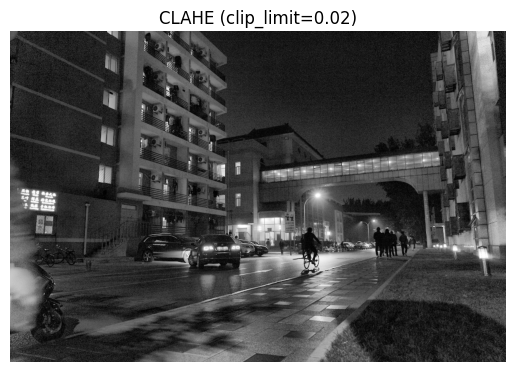

In [ ]:
# Aplicamos CLAHE con skimage sobre la imagen gray3 normalizada
clahe3 = exposure.equalize_adapthist(gray3, clip_limit=0.02, nbins=256)

# Mostramos la imagen resultante
plt.imshow(clahe3, cmap='gray')
plt.title("CLAHE (clip_limit=0.02)")
plt.axis('off')
plt.show()

#### 5.3.2 Suavizado mediante filtro bilateral

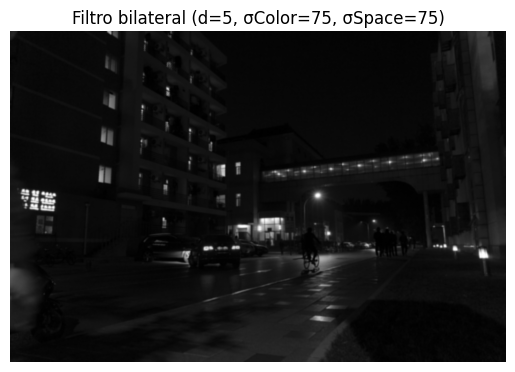

In [ ]:
# Aplicamos el filtro bilateral directamente sobre gray3 (rango [0,1])
bilateral3 = cv2.bilateralFilter(gray3.astype('float32'), d=5, sigmaColor=75, sigmaSpace=75)

# Mostramos la imagen suavizada
plt.imshow(bilateral3, cmap='gray')
plt.title("Filtro bilateral (d=5, σColor=75, σSpace=75)")
plt.axis('off')
plt.show()

**`cv2.bilateralFilter()`** aplica el filtro bilateral. Utiliza una doble ponderación:

- **Espacial**: los píxeles cercanos en distancia al píxel central tienen más influencia.
- **Rango**: los píxeles similares en intensidad al píxel central también tienen más peso.

Esto permite que el filtro **suavice regiones uniformes** sin difuminar los contornos donde hay diferencias de intensidad.

- **`gray3.astype('float32')`** convierte la imagen a tipo `float32`, necesario para que la función `cv2.bilateralFilter()` funcione correctamente. Aunque la imagen ya está normalizada en rango `[0,1]`, OpenCV requiere este tipo específico en imágenes con decimales.

- El parámetro **`d=9`** indica el **diámetro del vecindario** que se considera alrededor de cada píxel (en este caso, una ventana de 9x9 píxeles). Un valor más alto aumenta el área de influencia, pero también el coste computacional. Es un parámetro espacial.

- **`sigmaColor=75`** controla **cuánto influye la diferencia de intensidad** entre píxeles vecinos.

  - Si `sigmaColor` es alto, se permite más diferencia tonal al suavizar (el filtro es más permisivo).
  - Si es bajo, se suaviza solo entre píxeles muy parecidos en valor, preservando más el detalle.

- **`sigmaSpace=75`** define el **grado de influencia espacial**: cuánto afecta la distancia entre píxeles.

  - Valores altos permiten que píxeles más lejanos influyan en el suavizado si tienen intensidad similar.
  - Valores bajos restringen el efecto a píxeles muy cercanos.

#### 5.3.3 Realce mediante máscara de nitidez (*Unsharp Mas*k)

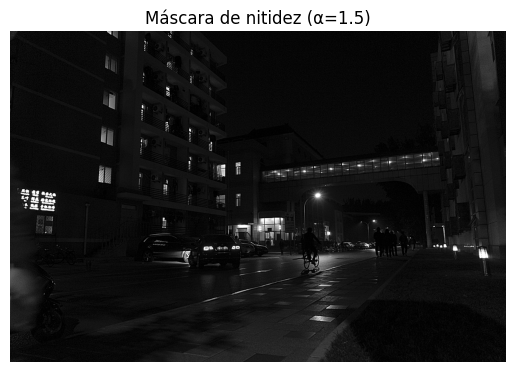

In [ ]:
# Aplicamos un filtro gaussiano para obtener una versión suavizada de la imagen
suavizada3 = gaussian_filter(gray3, sigma=1.0)

# Calculamos la imagen de detalle como la diferencia entre original y suavizada
detalle3 = gray3 - suavizada3

# Sumamos el detalle amplificado a la imagen original
unsharp3 = gray3 + 1.5 * detalle3

# Recortamos los valores para mantenerlos en el rango [0,1]
unsharp3 = np.clip(unsharp3, 0, 1)

# Mostramos la imagen realzada
plt.imshow(unsharp3, cmap='gray')
plt.title("Máscara de nitidez (α=1.5)")
plt.axis('off')
plt.show()

#### 5.3.4 Aumento del contraste por *stretching* lineal del histograma

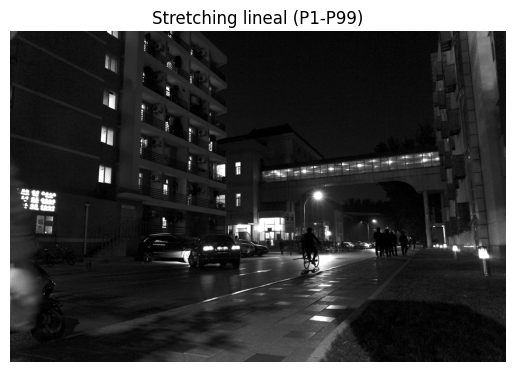

In [ ]:
# Calculamos los percentiles 1 y 99 para evitar valores extremos
p1, p99 = np.percentile(gray3, (1, 99))

# Aplicamos stretching lineal entre P1 y P99
stretch3 = (gray3 - p1) / (p99 - p1)

# Recortamos los valores fuera del rango [0,1]
stretch3 = np.clip(stretch3, 0, 1)

ecualizada3 = exposure.equalize_hist(gray3)

# Mostramos la imagen con contraste expandido
plt.imshow(stretch3, cmap='gray')
plt.title("Stretching lineal (P1-P99)")
plt.axis('off')
plt.show()

#### 5.3.5 Visualización comparativa de técnicas de realce, suavizado e histogramas

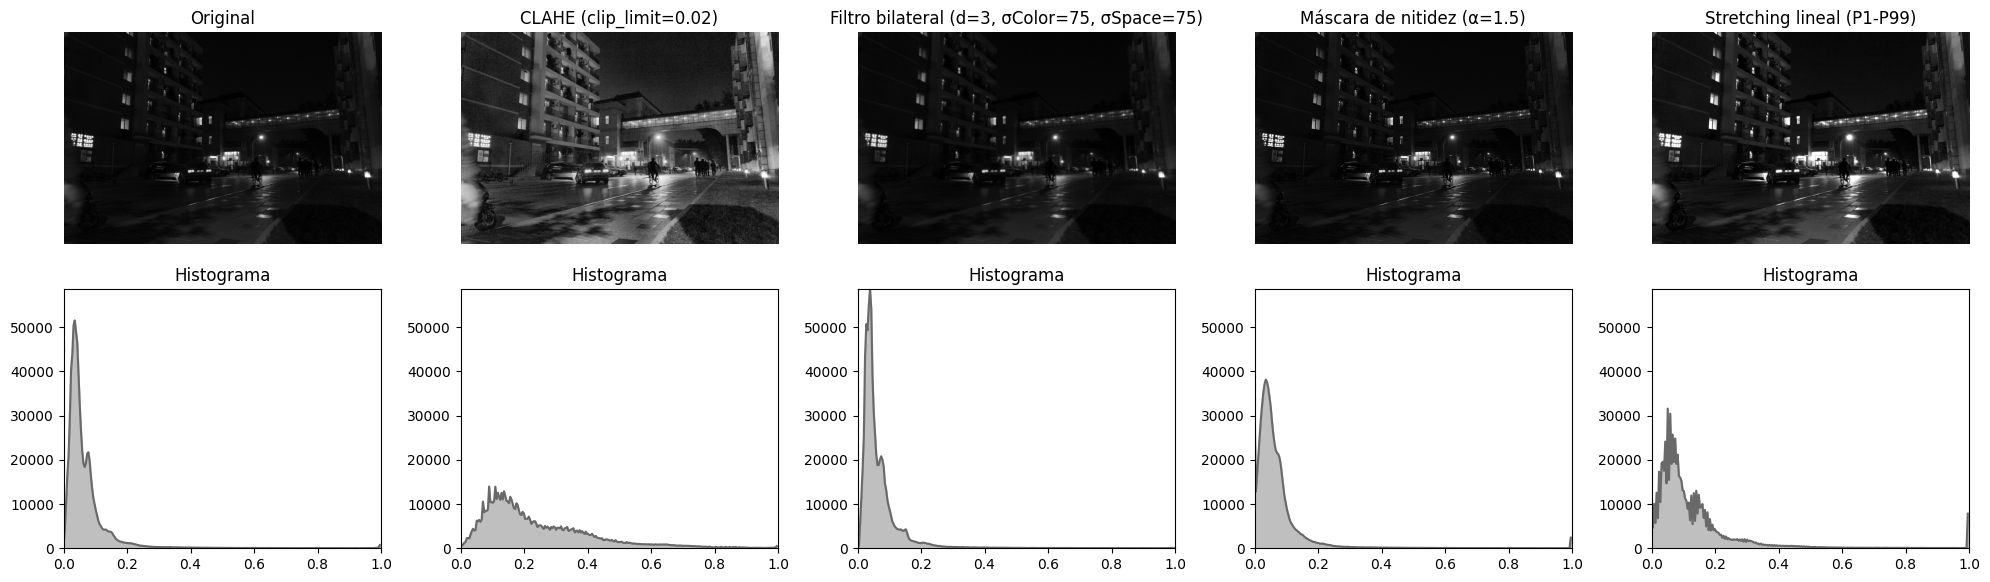

In [ ]:
# Creamos una figura 2x5: primera fila imágenes, segunda fila histogramas
fig, axes = plt.subplots(2, 5, figsize=(20, 6))

# Lista de imágenes y títulos
imagenes = [gray3, clahe3, bilateral3, unsharp3, stretch3]
titulos = ["Original", "CLAHE (clip_limit=0.02)", "Filtro bilateral (d=3, σColor=75, σSpace=75)", "Máscara de nitidez (α=1.5)", "Stretching lineal (P1-P99)"]

# Mostramos imágenes en la primera fila
for i in range(5):
    axes[0, i].imshow(imagenes[i], cmap='gray')
    axes[0, i].set_title(titulos[i])
    axes[0, i].axis("off")

# Calculamos el valor máximo entre todos los histogramas para unificar escala
max_val = max(np.histogram(img, bins=256, range=(0, 1))[0].max() for img in imagenes)

# Mostramos histogramas en la segunda fila
for i in range(5):
    hist, bins = np.histogram(imagenes[i], bins=256, range=(0, 1))
    axes[1, i].fill_between(bins[:-1], hist, color='grey', alpha=0.5) # Área traslúcida
    axes[1, i].plot(bins[:-1], hist, color='dimgrey', linewidth=1.5)  # Línea
    axes[1, i].set_title("Histograma")
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_ylim(0, max_val)  # Fijamos escala común
    axes[1, i].grid(False)

# Ajustamos diseño
plt.tight_layout()
plt.show()

La imagen muestra el resultado de aplicar cuatro técnicas distintas sobre una imagen nocturna caracterizada por amplias regiones muy oscuras.

En primer lugar, **CLAHE es la técnica que produce la transformación más notable** sobre la imagen. Aumenta de forma significativa la luminosidad general y revela detalles previamente ocultos en las zonas en sombra que en la imagen original resultaban casi imperceptibles. Sin embargo, este incremento del contraste local también introduce grano más marcado, especialmente en regiones oscuras, y la imagen adquiere una apariencia más “dura” o envejecida, típica de procesos agresivos de ecualización. El histograma mustra como la distribución se expande por todo el rango tonal y se reduce la fuerte concentración inicial en intensidades bajas, acercándose a una forma más uniforme. No obstante, esta redistribución también incrementa la presencia de altas luces y microvariaciones que no estaban originalmente presentes.

El **filtro bilateral**, por el contrario, tiene un efecto mucho más moderado. Su objetivo es reducir el ruido manteniendo los bordes, pero en esta imagen, donde el ruido está parcialmente asociado a las diferencias extremas de iluminación, el resultado es un suavizado perceptible que reduce parte del grano, aunque a costa de una ligera pérdida de nitidez en contornos finos. No produce mejoras directas en la visibilidad general, ya que no incrementa el contraste ni aclara los elementos oscuros. El histograma asociado mantiene en gran medida la forma del original, con un incremento leve en los valores de baja intensidad debido a la homogenización de zonas muy oscuras, pero sin cambios significativos en el rango dinámico.

La **máscara de nitidez** genera un efecto claramente distinto y visualmente más equilibrado que CLAHE. Realza las transiciones de intensidad, acentúa texturas del pavimento, bordes de vehículos, estructuras arquitectónicas y elementos del entorno urbano. El resultado es una imagen con mayor definición, especialmente en zonas donde la iluminación artificial crea transiciones abruptas. A diferencia de CLAHE, no aclara de forma global, por lo que la escena mantiene su carácter nocturno sin introducir ruido excesivo. El histograma muestra una ligera ampliación del rango tonal y una disminución en la concentración de valores muy oscuros, sin redistribuciones extremas.

Por último, el ***stretching* lineal del histograma** ofrece una mejora más suave y controlada del contraste. A diferencia de la ecualización global usada en el bloque anterior, que tendía a saturar luces y generar ruido, el *stretching* lineal expande el rango dinámico sin distorsionar drásticamentela distribución tonal. La imagen resultante mantiene su coherencia estética, con una ligera recuperación de detalle en las sombras y un incremento sutil de luminosidad en zonas moderadamente iluminadas, sin potenciar el grano ni alterar la textura original. El histograma refleja este comportamiento: se observa una expansión suave hacia los extremos, reduciendo parcialmente la acumulación inicial en intensidades bajas e incrementando de forma moderada los niveles altos, pero sin llegar a uniformizar la distribución como ocurre en CLAHE. Esto lo convierte en una opción adecuada cuando se busca mejorar la legibilidad visual sin comprometer la estructura original ni introducir artefactos.




#### 5.3.7 Evaluación cuantitativa de las técnicas de realce y suavizado aplicadas

In [ ]:
# Lista de imágenes y títulos
imagenes = [gray3, clahe3, bilateral3, unsharp3, stretch3]

# Lista de imágenes y nombres
imagenes = {
    "Original": gray3,
    "CLAHE": clahe3,
    "Filtro bilateral": bilateral3,
    "Máscara de nitidez": unsharp3,
    "Stretching": stretch3
}

# Calculamos las métricas
resultados = {}
for nombre, img in imagenes.items():
    contraste = img.std()  # Contraste RMS
    entropia = shannon_entropy(img)  # Entropía de Shannon
    brillo_medio = img.mean()  # Brillo medio
    p1 = np.percentile(img, 1)  # Percentil 1
    p99 = np.percentile(img, 99)  # Percentil 99

    resultados[nombre] = {
        "Contraste": contraste,
        "Entropía": entropia,
        "Brillo medio": brillo_medio,
        "P1 (1%)": p1,
        "P99 (99%)": p99
    }

# Mostramos los resultados en tabla
df_resultados = pd.DataFrame(resultados).T
display(df_resultados)

,Contraste,Entropía,Brillo medio,P1 (1%),P99 (99%)
Original,0.087277,11.918030,0.072130,0.008676,0.471631
CLAHE,0.172037,13.123040,0.243842,0.024635,0.820160
Filtro bilateral,0.081538,19.529197,0.072129,0.012450,0.447317
Máscara de nitidez,0.095915,19.144747,0.072371,0.000000,0.530808
Stretching,0.147163,11.737570,0.131690,0.000000,0.999999


La imagen **original** presenta un contraste bajo ($0.0873$) y un brillo medio reducido ($0.0721$), coherentes con su naturaleza nocturna. La entropía ($11.92$) indica cierta complejidad tonal a pesar del rango comprimido. Los percentiles (P1 $=0.0087$, P99 $=0.472$) reflejan la escasa presencia de zonas muy claras o saturadas.

**CLAHE** logra la mejora más visible, duplicando el contraste y triplicando el brillo medio. La entropía aumenta ($13.12$) y el histograma se redistribuye de forma más uniforme (P99 $=0.8201$). Sin embargo, este realce puede introducir ruido en sombras profundas.

El **filtro bilateral**, con el contraste más bajo ($0.0815$), no modifica el brillo, pero alcanza la entropía más alta ($19.53$), lo que refleja una alta variabilidad local. Su efecto tonal es limitado, aunque útil como paso de reducción de ruido.

La **máscara de nitidez** incrementa levemente el contraste ($0.0959$) y mantiene el brillo, pero aumenta la entropía ($19.14$) al realzar contornos y texturas. Su efecto es más estructural que tonal, con un P99 $=0.5308$ que indica cierta expansión en las luces.

El **stretching lineal** ofrece una mejora equilibrada del contraste ($0.1472$) y del brillo medio ($0.1317$), manteniendo una entropía similar a la original ($11.74$). Extiende el histograma hasta valores extremos (P99 $=0.9999$), pero de forma progresiva, sin los efectos agresivos de la ecualización global.

Los resultados obtenidos indican que ninguna de las técnicas aplicadas por sí sola es completamente óptima en esta imagen. Sin embargo, una combinación secuencial de técnicas permitiria **aprovechar las fortalezas de cada una**.

#### 5.3.8 Aplicación combinada de técnicas para mejora progresiva de la Imagen 3

En esta sección se aplicará, en primer lugar, un *stretching* lineal del histograma con el objetivo de ampliar el rango dinámico de manera controlada. A continuación, se utilizará un filtro bilateral para atenuar el posible ruido amplificado en las regiones oscuras tras el realce tonal. Finalmente, la aplicación de una máscara de nitidez permitirá reforzar contornos y texturas que previamente se encontraban difuminadas.

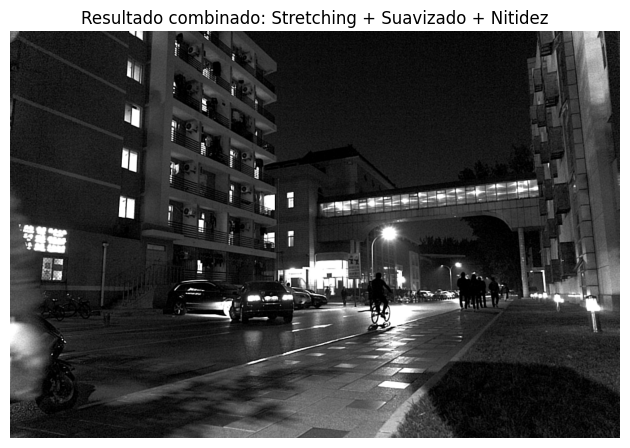

In [ ]:
# Aplicamos primero stretching lineal (p2–P99)
p2, p98 = np.percentile(gray3, (2, 98))  # Calculamos percentiles
stretch_comb = np.clip((gray3 - p2) / (p98 - p2), 0, 1)  # Stretching lineal

# Aplicamos filtro bilateral para suavizar el ruido
# Convertimos a float32 para mayor compatibilidad
bilateral_comb = cv2.bilateralFilter(stretch_comb.astype('float32'), d=3, sigmaColor=75, sigmaSpace=75)

# Aplicamos máscara de nitidez sobre la imagen suavizada
# Primero generamos una imagen suavizada con filtro gaussiano para construir la máscara
gauss_soft = ndimage.gaussian_filter(bilateral_comb, sigma=1.0)

# Calculamos la máscara de alta frecuencia
mask = bilateral_comb - gauss_soft

# Combinamos con la imagen suavizada para realzar bordes (alpha=1.5)
combined_final = bilateral_comb + 1.5 * mask

# Nos aseguramos de que los valores están en el rango [0,1]
combined_final = np.clip(combined_final, 0, 1)

# Mostramos el resultado final
plt.imshow(combined_final, cmap='gray')
plt.title("Resultado combinado: Stretching + Suavizado + Nitidez")
plt.axis("off")
plt.tight_layout()
plt.show()

##### 5.3.8.1 Visualización comparativa de técnicas combinadas

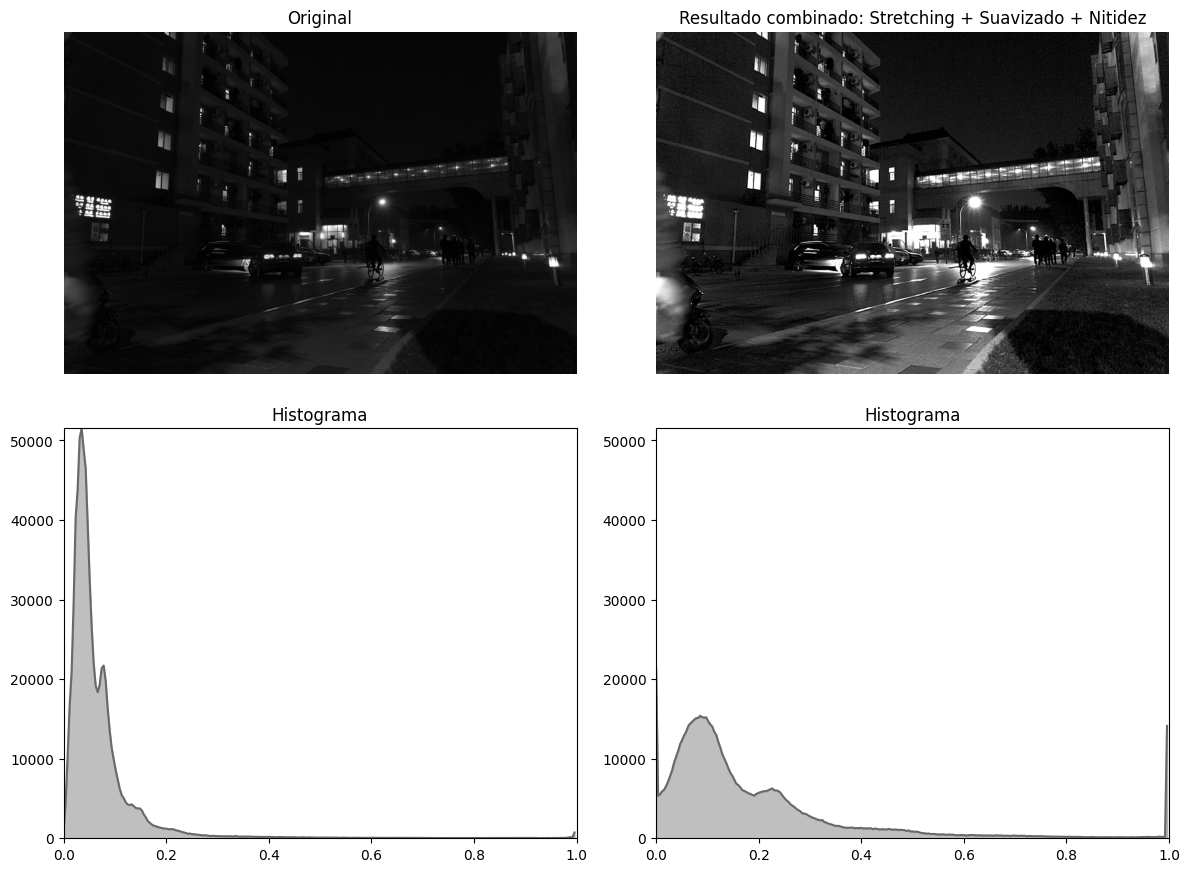

In [ ]:
# Creamos una figura 2x5: primera fila imágenes, segunda fila histogramas
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Lista de imágenes y títulos
imagenes = [gray3, combined_final]
titulos = ["Original", "Resultado combinado: Stretching + Suavizado + Nitidez"]

# Mostramos imágenes en la primera fila
for i in range(2):
    axes[0, i].imshow(imagenes[i], cmap='gray')
    axes[0, i].set_title(titulos[i])
    axes[0, i].axis("off")

# Calculamos el valor máximo entre todos los histogramas para unificar escala
max_val = max(np.histogram(img, bins=256, range=(0, 1))[0].max() for img in imagenes)

# Mostramos histogramas en la segunda fila
for i in range(2):
    hist, bins = np.histogram(imagenes[i], bins=256, range=(0, 1))
    axes[1, i].fill_between(bins[:-1], hist, color='grey', alpha=0.5) # Área traslúcida
    axes[1, i].plot(bins[:-1], hist, color='dimgrey', linewidth=1.5)  # Línea
    axes[1, i].set_title("Histograma")
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_ylim(0, max_val)  # Fijamos escala común
    axes[1, i].grid(False)

# Ajustamos diseño
plt.tight_layout()
plt.show()

En la imagen resultante, se observa una mejora visual notable respecto a la original. Las zonas oscuras, que antes ocultaban detalle, se aclaran de manera efectiva tras la expansión del histograma mediante *stretching*. El histograma confirma esta redistribución pasa de una fuerte acumulación en intensidades bajas (original) a una distribución más uniforme, con mayor presencia en zonas medias y altas. No obstante, esta mejora implica como contrapartida que algunas regiones muy iluminadas alcancen niveles cercanos a la saturación, como se refleja en el pico final del histograma combinado.

La aplicación del **filtro bilateral** sobre la imagen estirada permite atenuar el ruido amplificado por el realce, manteniendo bordes definidos.

Finalmente, la **máscara de nitidez** intensifica los contornos sin alterar el brillo global, añadiendo textura y realce local sin degradar el resultado previo.

##### 5.3.8.2 Evaluación cuantitativa de las técnicas combinadas

In [ ]:
# Lista de imágenes y títulos
imagenes = [gray3, combined_final]

# Lista de imágenes y nombres
imagenes = {
    "Original": gray3,
    "Resultado combinado": combined_final
}

# Calculamos las métricas
resultados = {}
for nombre, img in imagenes.items():
    contraste = img.std()  # Contraste RMS
    entropia = shannon_entropy(img)  # Entropía de Shannon
    brillo_medio = img.mean()  # Brillo medio
    p1 = np.percentile(img, 1)  # Percentil 1
    p99 = np.percentile(img, 99)  # Percentil 99

    resultados[nombre] = {
        "Contraste": contraste,
        "Entropía": entropia,
        "Brillo medio": brillo_medio,
        "P1 (1%)": p1,
        "P99 (99%)": p99
    }

# Mostramos los resultados en tabla
df_resultados = pd.DataFrame(resultados).T
display(df_resultados)

,Contraste,Entropía,Brillo medio,P1 (1%),P99 (99%)
Original,0.087277,11.918030,0.072130,0.008676,0.471631
Resultado combinado,0.191721,19.009852,0.188928,0.000000,1.000000


Los resultados cuantitativos confirman la mejora significativa obtenida tras la combinación secuencial de *stretching*, suavizado y realce. El **contraste** prácticamente se duplica respecto a la imagen original ($0.0873 \rightarrow 0.1917$), lo que refleja una expansión eficaz del rango tonal. Esta transformación no solo mejora la diferenciación entre estructuras visuales, sino que lo hace sin introducir saturaciones masivas en el rango medio.

La **entropía** aumenta de forma considerable ($11.92 \rightarrow 19.01$), lo que indica una mayor diversidad de intensidades y riqueza de información visual. Este aumento se debe tanto al *stretching* como a la posterior recuperación de detalle mediante la máscara de nitidez. El **brillo medio** también se incrementa de forma notable ($0.0721 \rightarrow 0.1889$), reforzando la percepción general de claridad sin desplazar completamente la imagen hacia niveles altos.

En cuanto a los **percentiles**, P1 $=0.0$ revela que se han mantenido valores mínimos en las sombras profundas, lo que favorece el contraste global, mientras que P99 $=1.0$ confirma que algunas zonas alcanzan el blanco absoluto, evidenciando un ligero riesgo de saturación en altas luces. Sin embargo, esta saturación puntual parece estar compensada por la ganancia global en detalle y legibilidad.


Esta aproximación demuestra cómo el procesamiento combinado permite mejorar de forma clara la visibilidad, el contraste local y la nitidez percibida, al tiempo que conserva una distribución tonal más rica y equilibrada. Se evidencia así la efectividad de encadenar técnicas complementarias para obtener un resultado final más informativo y visualmente coherente.

### 5.4 Procesamiento combinado aplicado a la Imagen 4: evaluación de estrategias encadenadas

En esta sección se evaluará la efectividad de aplicar **procesamientos combinados en secuencia** sobre la Imagen 4, una escena urbana nocturna con alta complejidad visual. A diferencia de los bloques anteriores, donde se analizaban técnicas individuales, aquí se construirá un *pipeline* con varias transformaciones encadenadas, seleccionadas entre aquellas que han ofrecido mejores resultados en fases previas del trabajo y complementadas con nuevas estrategias no exploradas anteriormente.

El objetivo es comprobar si la combinación de técnicas permite **superar las limitaciones de cada procedimiento por separado**, maximizando el realce de estructuras relevantes (peatones, vehículos, luces) sin comprometer la fidelidad visual ni introducir artefactos. La escena es particularmente adecuada para este enfoque, ya que presenta **amplias zonas en sombra, reflejos difusos y elementos en movimiento**, lo que exige un tratamiento equilibrado entre contraste, suavizado y nitidez.

#### 5.4.1 *Pipeline* de mejora visual aplicado a escenas nocturnas complejas

##### 5.4.1.1 Realce de sombras y ampliación tonal

Técnicas destinadas a aumentar la visibilidad en zonas oscuras y expandir el rango dinámico sin comprometer el equilibrio global.

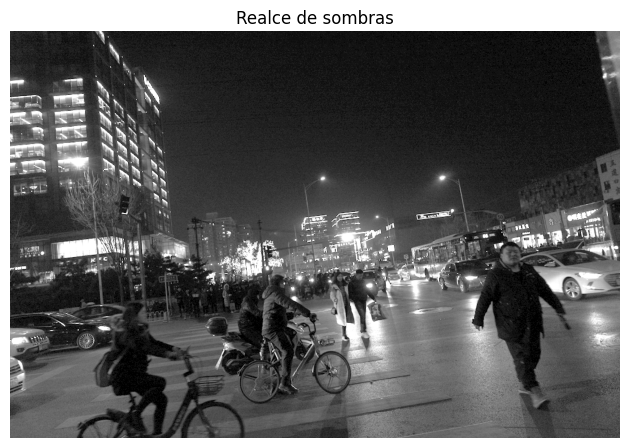

In [ ]:
# Aplicamos una transformación gamma con gamma < 1 para levantar sombras
gamma = 0.4
image_gamma = np.power(gray4, gamma)

# Aplicamos stretching lineal entre percentiles P2 y P98 para expandir el rango dinámico
p2, p98 = np.percentile(image_gamma, (2, 98))
image_stretch = np.clip((image_gamma - p2) / (p98 - p2), 0, 1)

# Mostramos el resultado final
plt.imshow(image_stretch, cmap='gray')
plt.title("Realce de sombras")
plt.axis("off")
plt.tight_layout()
plt.show()

##### 5.4.1.2 Reducción de ruido con preservación de bordes

Aplicación de filtros avanzados para suprimir el ruido sin perder definición en contornos estructurales.

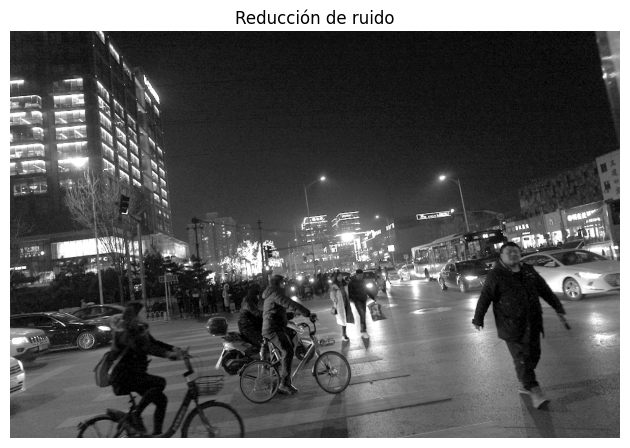

In [ ]:
# Aplicamos un filtro gaussiano suave para reducir el ruido sin borrar contornos importantes
image_denoised = ndimage.gaussian_filter(image_stretch, sigma=0.2)

# Mostramos el resultado final
plt.imshow(image_denoised, cmap='gray')
plt.title("Reducción de ruido")
plt.axis("off")
plt.tight_layout()
plt.show()

##### 5.4.1.3 Mejora de bordes y texturas clave

Técnicas de realce selectivo que fortalecen la percepción de detalles relevantes como peatones, vehículos o señales.

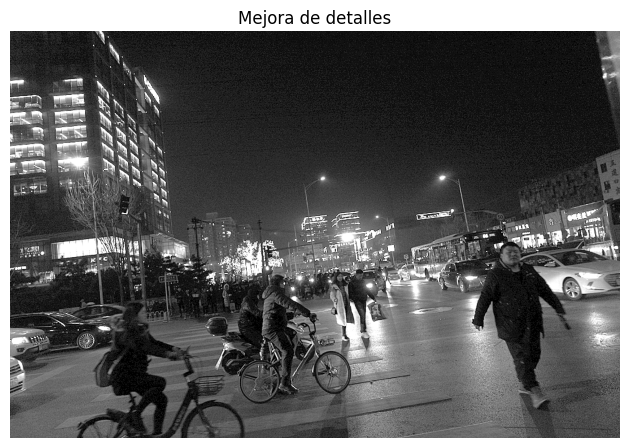

In [ ]:
# Generamos una versión suavizada de referencia para extraer detalles finos
soft_reference = ndimage.gaussian_filter(image_denoised, sigma=1)

# Calculamos la máscara de alta frecuencia (detalle realzado)
mask = image_denoised - soft_reference

# Aplicamos la máscara con un factor de refuerzo (alpha = 1.5)
image_sharpened = image_denoised + 1 * mask

# Aseguramos que los valores finales estén dentro del rango válido [0, 1]
image_sharpened_clipped = np.clip(image_sharpened, 0, 1)

# Mostramos el resultado final
plt.imshow(image_sharpened_clipped, cmap='gray')
plt.title("Mejora de detalles")
plt.axis("off")
plt.tight_layout()
plt.show()

##### 5.4.1.4 Suavizado final para estabilizar la imagen y reducir artefactos

Aplicación de un filtrado gaussiano ligero para homogeneizar la textura, minimizar irregularidades y atenuar artefactos residuales sin comprometer la nitidez global.

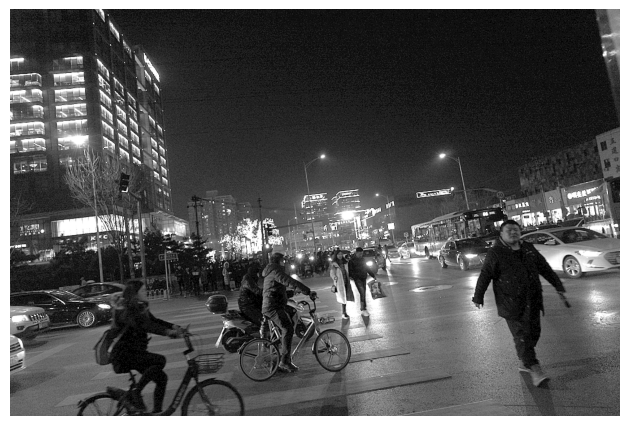

In [ ]:
image_final = ndimage.gaussian_filter(image_sharpened_clipped, sigma=0.4)

# Mostramos el resultado final
plt.imshow(image_final, cmap='gray')
plt.title("")
plt.axis("off")
plt.tight_layout()
plt.show()

#### 5.4.2 Evaluación visual y métrica del *pipeline* completo

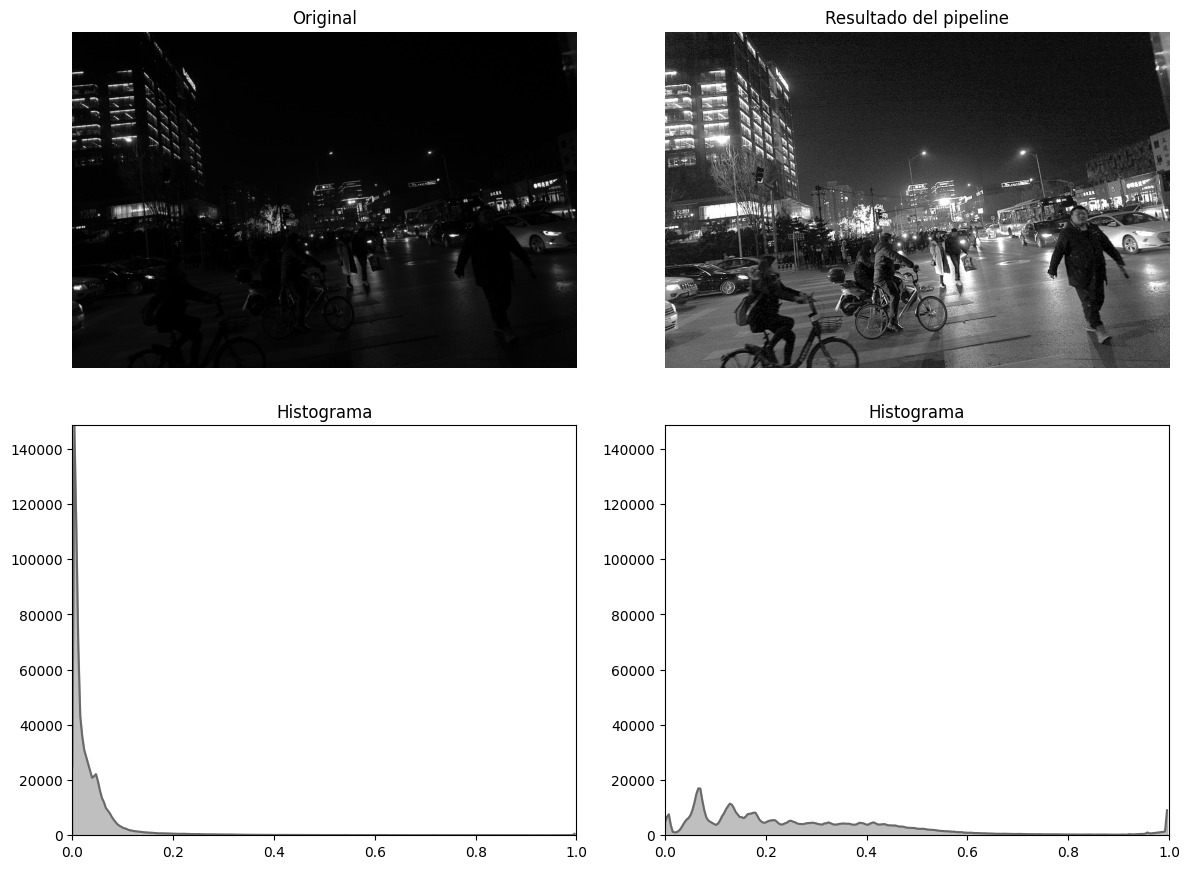

In [ ]:
# Creamos figura comparativa 2x2: imágenes y sus histogramas
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Lista de imágenes y títulos
imagenes = [gray4, image_final]
titulos = ["Original", "Resultado del pipeline"]

# Mostramos imágenes en la primera fila
for i in range(2):
    axes[0, i].imshow(imagenes[i], cmap='gray')
    axes[0, i].set_title(titulos[i])
    axes[0, i].axis("off")

# Calculamos valor máximo para unificar escala de histogramas
max_val = max(np.histogram(img, bins=256, range=(0, 1))[0].max() for img in imagenes)

# Mostramos histogramas en la segunda fila
for i in range(2):
    hist, bins = np.histogram(imagenes[i], bins=256, range=(0, 1))
    axes[1, i].fill_between(bins[:-1], hist, color='grey', alpha=0.5)
    axes[1, i].plot(bins[:-1], hist, color='dimgrey', linewidth=1.5)
    axes[1, i].set_title("Histograma")
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_ylim(0, max_val)
    axes[1, i].grid(False)

# Ajustamos el diseño
plt.tight_layout()
plt.show()

Tras aplicar el *pipeline*, se aprecia una mejora notable en la visibilidad general de la escena. Las zonas oscuras, anteriormente poco legibles, ahora revelan contornos de peatones, bicicletas y detalles del pavimento. Al mismo tiempo, los elementos brillantes, como farolas, faros de vehículos o rótulos luminosos, mantienen su presencia sin llegar a saturarse de forma excesiva, gracias al control en el estiramiento dinámico y el suavizado posterior.

El histograma del resultado final muestra una redistribución tonal mucho más rica. La acumulación inicial en valores bajos se ha dispersado, permitiendo una ocupación más uniforme del rango de intensidades. Se observa un pico secundario en torno a valores medios ($\approx [0.2–0.3]$), lo cual sugiere una mejor representación de los tonos intermedios, esenciales para percibir profundidad y textura. El incremento en los valores altos, aunque presenta una pequeña acumulación en el extremo derecho, está dentro de lo esperado tras una expansión dinámica, y se ha controlado eficazmente mediante la reducción de ruido final.

El *pipeline* logra equilibrar los tres objetivos fundamentales del procesamiento de imágenes nocturnas: **aclarar las zonas oscuras, preservar o realzar bordes importantes y evitar artefactos por sobreprocesamiento**. El resultado es visualmente más informativo, mejor adaptado a tareas de interpretación, y con una estructura tonal más aprovechada, tal como refleja el histograma.

#### 5.4.3 Evaluación cuantitativa del *pipeline* completo

In [ ]:
# Lista de imágenes y títulos
imagenes = [gray4, image_final]

# Lista de imágenes y nombres
imagenes = {
    "Original": gray4,
    "Procesado completo": image_final
}

# Calculamos las métricas
resultados = {}
for nombre, img in imagenes.items():
    contraste = img.std()  # Contraste RMS
    entropia = shannon_entropy(img)  # Entropía de Shannon
    brillo_medio = img.mean()  # Brillo medio
    p1 = np.percentile(img, 1)  # Percentil 1
    p99 = np.percentile(img, 99)  # Percentil 99

    resultados[nombre] = {
        "Contraste": contraste,
        "Entropía": entropia,
        "Brillo medio": brillo_medio,
        "P1 (1%)": p1,
        "P99 (99%)": p99
    }

# Mostramos los resultados en tabla
df_resultados = pd.DataFrame(resultados).T
display(df_resultados)

,Contraste,Entropía,Brillo medio,P1 (1%),P99 (99%)
Original,0.086278,9.439934,0.042915,0.001116,0.472131
Procesado completo,0.217645,19.540759,0.278638,0.004993,0.998631


Los resultados numéricos confirman de manera objetiva la efectividad del *pipeline* aplicado sobre la Imagen 4. La imagen original presenta un contraste bajo ($0.0863$), una entropía limitada ($9.44$) y un brillo medio muy reducido ($0.0429$), todos ellos indicadores de una escena fuertemente subexpuesta con escasa variabilidad tonal. Los percentiles extremos (P2 $=0.0011$, P98 $=0.4721$) muestran una distribución tonal muy comprimida, sin aprovechar el rango completo de intensidades disponibles.

En cambio, la imagen procesada muestra una mejora sustancial en todos los indicadores. El contraste se incrementa significativamente hasta $0.2176$, lo que refleja una mayor separación entre regiones oscuras y claras, mejorando la legibilidad de estructuras internas. La entropía, que se duplica hasta $19.54$, indica un aumento drástico en la riqueza de información visual, con una distribución mucho más compleja y diversa de tonos.

El brillo medio también se incrementa de forma notable ($0.2786$), lo que se traduce en una imagen globalmente más clara y equilibrada. Además, los percentiles (P2 $=0.0050$, P98 $=0.9986$) muestran que el procesamiento ha conseguido expandir el rango dinámico casi hasta sus límites, sin saturaciones extremas. Esto confirma que el *pipeline* no solo mejora el aspecto visual, sino que también redistribuye eficazmente las intensidades, permitiendo aprovechar todo el espacio tonal disponible sin pérdida de detalle relevante.

### 6. Conclusiones

Los resultados obtenidos confirman que **no existe una técnica única capaz de mejorar globalmente imágenes nocturnas** con éxito en todos los contextos. Mientras que algunas transformaciones como *gamma correction* o *stretching* resultan eficaces para incrementar el contraste y levantar sombras, otras como *CLAHE* o *ecualización del histograma* ofrecen una mejora más agresiva que, si bien revela detalles ocultos, puede introducir ruido no deseado en regiones oscuras. Del mismo modo, los filtros espaciales como: media, mediana, gaussiano o bilateral, muestran un comportamiento dispar, destacando el gaussiano como una opción equilibrada para suavizar sin pérdida excesiva de estructura.

El análisis individual por imagen ha permitido ajustar las transformaciones en función de las características de cada escena, valorando su efecto mediante métricas como el contraste, la entropía, el brillo medio o los percentiles extremos. Estas métricas han demostrado ser útiles para objetivar el impacto de cada técnica, evidenciando mejoras sustanciales en los valores tras los procesamientos, especialmente en términos de rango dinámico y riqueza tonal.

Sin embargo, ha sido en los bloques de procesamiento combinado, especialmente sobre las Imágenes 3 y 4, donde se ha alcanzado un resultado óptimo tanto a nivel visual como cuantitativo. La integración secuencial de transformaciones cuidadosamente seleccionadas (por ejemplo, *gamma*, *stretching*, suavizado gaussiano, realce mediante *unsharp masking* y post-suavizado) ha permitido **equilibrar los efectos deseados de contraste, nitidez y control del ruido**, generando imágenes más informativas, legibles y coherentes con su contexto visual original.

Estas combinaciones han demostrado que encadenar técnicas complementarias puede **superar las limitaciones de cada método aplicado de forma aislada**, logrando un resultado final que aprovecha al máximo el rango tonal disponible sin sacrificar detalles ni introducir artefactos. En particular, el *pipeline* desarrollado para la Imagen 4 ha duplicado la entropía, quintuplicado el brillo medio y extendido el rango dinámico casi en su totalidad, sin saturación excesiva ni distorsión visual.

Los resultados obtenidos refuerzan la utilidad de este tipo de estrategias en entornos como la visión artificial, la seguridad urbana o la mejora de capturas en condiciones adversas.